## Exploratory Data Analysis (EDA)

## 1. Understand the Problem: 

A bank wants to predict which customers are likely to churn (leave the bank). By identifying at-risk customers early, the bank can offer targeted promotions and personalized services to retain them.

Target Column: Churn --> Whether a customer left the bank (yes) or stayed (no).


## 2. Load and Inspect the Dataset: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

bank_customer_analytics = pd.read_csv(r'bank_customer_analytics.csv')
bank_customer_analytics

# 3000 πελάτες της τράπεζας με 12 χαρακτηριστικά (Features)

,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
0,C0001,25.00,FEMALE,single,80000.00,15000.00,600.00,50000.00,approved,joint,NaN,no
1,C0002,35.00,male,single,40000.00,5000.00,700.00,40000.00,approved,joint,10.00,no
2,C0003,35.00,female,single,100000.00,20000.00,800.00,50000.00,defaulted,checking,10.00,no
3,C0004,45.00,male,married,80000.00,20000.00,750.00,30000.00,approved,checking,NaN,no
4,C0005,45.00,male,married,40000.00,25000.00,750.00,20000.00,rejected,checking,2.00,yes
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,C2996,35.00,female,single,80000.00,NaN,800.00,30000.00,rejected,checking,2.00,yes
2996,C2997,35.00,male,single,100000.00,25000.00,600.00,40000.00,approved,checking,5.00,no
2997,C2998,45.00,FEMALE,single,80000.00,5000.00,750.00,40000.00,approved,investment,NaN,yes
2998,C2999,45.00,FEMALE,married,80000.00,15000.00,NaN,NaN,approved,savings,5.00,no


In [134]:
bank_customer_analytics.columns.to_list # Επιβεβαίωση των χαρακτηριστικών των στηλών

<bound method IndexOpsMixin.tolist of Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'Income', 'Savings',
       'CreditScore', 'LoanAmount', 'LoanStatus', 'AccountType',
       'YearsWithBank', 'Churn'],
      dtype='object')>

In [136]:
bank_customer_analytics.head() # Τσεκάρω πρώτες 5 γραμμές

# Παρατηρώ πως φαίνεται στη στήλη Gender να λέει είτε FEMALE είτε female. Θέλει φτιάξιμο αυτό.
# Κάποιες NaN values στα έτη συνεργασίας με την τράπεζα.

,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
0,C0001,25.00,FEMALE,single,80000.00,15000.00,600.00,50000.00,approved,joint,NaN,no
1,C0002,35.00,male,single,40000.00,5000.00,700.00,40000.00,approved,joint,10.00,no
2,C0003,35.00,female,single,100000.00,20000.00,800.00,50000.00,defaulted,checking,10.00,no
3,C0004,45.00,male,married,80000.00,20000.00,750.00,30000.00,approved,checking,NaN,no
4,C0005,45.00,male,married,40000.00,25000.00,750.00,20000.00,rejected,checking,2.00,yes


In [137]:
bank_customer_analytics.tail() # Τσεκάρω τελευταίες 5 γραμμές

# Κάποιες NaN values στα Savings, CreditScore, LoanAmount

,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
2995,C2996,35.00,female,single,80000.00,NaN,800.00,30000.00,rejected,checking,2.00,yes
2996,C2997,35.00,male,single,100000.00,25000.00,600.00,40000.00,approved,checking,5.00,no
2997,C2998,45.00,FEMALE,single,80000.00,5000.00,750.00,40000.00,approved,investment,NaN,yes
2998,C2999,45.00,FEMALE,married,80000.00,15000.00,NaN,NaN,approved,savings,5.00,no
2999,C3000,35.00,female,single,80000.00,20000.00,600.00,30000.00,approved,savings,NaN,no


In [138]:
bank_customer_analytics.sample(10) # Τσεκάρω 10 τυχαίες γραμμές

,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
450,C0451,NaN,female,married,80000.00,10000.00,800.00,40000.00,rejected,investment,10.00,no
936,C0937,35.00,Male,widowed,100000.00,15000.00,650.00,40000.00,rejected,investment,1.00,yes
1436,C1437,35.00,female,widowed,80000.00,20000.00,650.00,20000.00,approved,joint,2.00,no
802,C0803,55.00,male,single,40000.00,10000.00,700.00,40000.00,rejected,investment,2.00,yes
92,C0093,55.00,female,single,60000.00,15000.00,700.00,20000.00,rejected,checking,2.00,no
2643,C2644,35.00,male,divorced,60000.00,10000.00,800.00,40000.00,approved,joint,5.00,no
1565,C1566,45.00,female,married,40000.00,20000.00,600.00,40000.00,rejected,checking,10.00,no
868,C0869,45.00,FEMALE,married,40000.00,25000.00,600.00,20000.00,rejected,joint,2.00,yes
1669,C1670,45.00,Male,widowed,60000.00,50000.00,650.00,30000.00,defaulted,investment,10.00,yes
368,C0369,55.00,Male,divorced,60000.00,10000.00,NaN,20000.00,defaulted,joint,5.00,no


In [139]:
bank_customer_analytics.dtypes         # Τσεκάρω στις στήλες τι datatypes είναι

CustomerID        object
Age              float64
Gender            object
MaritalStatus     object
Income           float64
Savings          float64
CreditScore      float64
LoanAmount       float64
LoanStatus        object
AccountType       object
YearsWithBank    float64
Churn             object
dtype: object

In [140]:
bank_customer_analytics.info() # Για να πάρω καλύτερα όλη την πληροφορία

#  Εδώ φαίνονται καλύτερα τα NaN values στο Age, Income, Savings, CreditScore, LoanAmount, YearsWithBank. Άρα έχουμε NaN values σε 6 από τις 12 στήλες χαρακτηριστικών.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     3000 non-null   object 
 1   Age            2838 non-null   float64
 2   Gender         3000 non-null   object 
 3   MaritalStatus  3000 non-null   object 
 4   Income         2865 non-null   float64
 5   Savings        2854 non-null   float64
 6   CreditScore    2857 non-null   float64
 7   LoanAmount     2867 non-null   float64
 8   LoanStatus     3000 non-null   object 
 9   AccountType    3000 non-null   object 
 10  YearsWithBank  2713 non-null   float64
 11  Churn          3000 non-null   object 
dtypes: float64(6), object(6)
memory usage: 281.4+ KB


In [141]:
bank_customer_analytics.isnull().sum() # Επιβεβαίωση το πόσα NaN values έχουμε στις 6 στήλες χαρακτηριστικών που τα έχουμε

CustomerID         0
Age              162
Gender             0
MaritalStatus      0
Income           135
Savings          146
CreditScore      143
LoanAmount       133
LoanStatus         0
AccountType        0
YearsWithBank    287
Churn              0
dtype: int64

In [142]:
# Να τσεκάρω τι % NaN values έχω ανά χαρακτηριστικό για τα 6 χαρακτηριστικά που έχω NaN values
NaN_values_sum = bank_customer_analytics.isna().sum()
NaN_values_percentage = (NaN_values_sum / len(bank_customer_analytics) * 100).round(2)
pd.DataFrame({'NaN_values_sum': NaN_values_sum, 'NaN_values_percentage': NaN_values_percentage})

# Βλέπω ότι σε καμία στήλη δεν λείπει πάνω από το 10% των NaN. Κρατάω στο YearsWithBank το ένα πιθανό outlier των 100 ετών.

,NaN_values_sum,NaN_values_percentage
CustomerID,0,0.00
Age,162,5.40
Gender,0,0.00
MaritalStatus,0,0.00
Income,135,4.50
Savings,146,4.87
CreditScore,143,4.77
LoanAmount,133,4.43
LoanStatus,0,0.00
AccountType,0,0.00


In [108]:
bank_customer_analytics.describe()     # statistics (mean, min, max κλπ)

,Age,Income,Savings,CreditScore,LoanAmount,YearsWithBank
count,2838.000000,2865.000000,2854.000000,2857.000000,2867.000000,2713.000000
mean,39.048626,68293.193717,21483.882270,694.662233,34080.920823,6.883155
std,9.816456,19997.850070,20893.054327,68.907793,9972.978607,5.907284
min,25.000000,40000.000000,5000.000000,600.000000,20000.000000,1.000000
25%,35.000000,60000.000000,10000.000000,650.000000,30000.000000,2.000000
50%,35.000000,60000.000000,15000.000000,700.000000,30000.000000,5.000000
75%,45.000000,80000.000000,20000.000000,750.000000,40000.000000,10.000000
max,55.000000,100000.000000,200000.000000,800.000000,50000.000000,100.000000


In [143]:
pd.set_option('display.float_format', '{:.2f}'.format) # Για να το διαβάζω καλύτερα
bank_customer_analytics.describe()

#pd.reset_option('display.float_format') #αν θέλω να το κάνω reset

# Εδώ παρατηρώ στη στήλη YearsWithBank στο max = 100. Είναι πολύ μεγάλη διάρκεια για κάποιον να συνεργαστεί με μία τράπεζα. Πιθανό outlier

# Γενικά σε αυτό το dataset βλέπω ότι το mean από το median δεν έχουν μεγάλες διαφορές

,Age,Income,Savings,CreditScore,LoanAmount,YearsWithBank
count,2838.00,2865.00,2854.00,2857.00,2867.00,2713.00
mean,39.05,68293.19,21483.88,694.66,34080.92,6.88
std,9.82,19997.85,20893.05,68.91,9972.98,5.91
min,25.00,40000.00,5000.00,600.00,20000.00,1.00
25%,35.00,60000.00,10000.00,650.00,30000.00,2.00
50%,35.00,60000.00,15000.00,700.00,30000.00,5.00
75%,45.00,80000.00,20000.00,750.00,40000.00,10.00
max,55.00,100000.00,200000.00,800.00,50000.00,100.00


### Replacing Outlier in col YearsWithBank with NaN

In [144]:
# Θα αντικαταστήσω το 100 (outlier) στην στήλη YearsWithBank με NaN πριν το βήμα 3. Handle Missing Values.
# Σε πόσες γραμμές υπάρχει αυτό το 100ρι.

print(f'Rows with YearsWithBank = 100: {(bank_customer_analytics["YearsWithBank"] == 100).sum()}')
bank_customer_analytics.loc[bank_customer_analytics['YearsWithBank'] == 100, 'YearsWithBank'] = np.nan
print('Outlier replaced with NaN.')

Rows with YearsWithBank = 100: 1
Outlier replaced with NaN.


### Flag missing values with a new binary column

In [145]:
# Flag missing values with a new binary column
# We create a new column for each feature that had missing values
# 1 = this row had a missing value originally
# 0 = this row had a real value originally
# This preserves the information that a value was missing even after imputation

missing_cols = ['Age', 'Income', 'Savings', 'CreditScore', 'LoanAmount', 'YearsWithBank']

for col in missing_cols:
    bank_customer_analytics[f'{col}_was_missing'] = bank_customer_analytics[col].isna().astype(int)
    
print('Missing value flags created:')
print([f'{col}_was_missing' for col in missing_cols])
print()
print('Example - how many rows were flagged per column:')
for col in missing_cols:
    flagged = bank_customer_analytics[f'{col}_was_missing'].sum()
    print(f'{col}_was_missing: {flagged} rows flagged')

Missing value flags created:
['Age_was_missing', 'Income_was_missing', 'Savings_was_missing', 'CreditScore_was_missing', 'LoanAmount_was_missing', 'YearsWithBank_was_missing']

Example - how many rows were flagged per column:
Age_was_missing: 162 rows flagged
Income_was_missing: 135 rows flagged
Savings_was_missing: 146 rows flagged
CreditScore_was_missing: 143 rows flagged
LoanAmount_was_missing: 133 rows flagged
YearsWithBank_was_missing: 288 rows flagged


### Drop flag columns --> Τα πετάω γιατί μετά δημιουργούν πρόβλημα


In [146]:
flag_cols = [col for col in bank_customer_analytics.columns if '_was_missing' in col]
bank_customer_analytics.drop(columns=flag_cols, inplace=True)
print(f'Shape after dropping flag columns: {bank_customer_analytics.shape}')

# Αν δεν τα πετάξω τότε θα έχω (3000, 18) αντί για (3000, 12) οπότε τα διώνχνω


Shape after dropping flag columns: (3000, 12)


## 3. Handle Missing Values: 

Θα πάω με 2 μεθόδους εδώ. Με Median imputation και θα δοκιμάσω και KNN imputation. Θα κάνω και μία σύγκριση αυτών των 2.

### Μέθοδος 1 - KNN Imputation (ως κύρια μέθοδος)

In [147]:
# Κάνω το df copy για να γίνουν εκεί οι αλλαγές
# Η ΚΝΝ γεμίζει τα NaN σε μία γραμμή - έναν πελάτη δηλαδή, βάσει των γραμμών - πελατών με παρόμοια χαρακτηριστικά με αυτά που θέλω να γεμίσω στον πελάτη μου που έχει NaN σε κάποιο χαρακτηριστικά από αυτά.
# Βάζω κ =5 άρα ψάχνω όλο το dataset να βρω κάθε φορά τους 5 πελάτες με τα πιο παρόμοια χαρακτηριστικά σε σχέση με αυτά που θέλω να γεμίσω στον πελάτη μου που έχει NaN
# KNN Μόνο σε numerical στήλες. Και οι 6 που έχω NaN είναι numerical

# Μπορώ να τρέξω μαζί το KNN Imputation με το Median Imputation καθώς σε κάθε μέθοδο έχω κάνει copy το dataframe

bank_customer_analytics_knn = bank_customer_analytics.copy()

numerical_columns = ['Age', 'Income', 'Savings', 'CreditScore', 'LoanAmount', 'YearsWithBank']

knn_imputer = KNNImputer(n_neighbors=5) # Library from sklearn.impute import KNNImputer
bank_customer_analytics_knn[numerical_columns] = knn_imputer.fit_transform(bank_customer_analytics_knn[numerical_columns])

print('KNN Imputation ---DONE---.')

bank_customer_analytics_knn[numerical_columns].isna().sum()

KNN Imputation ---DONE---.


Age              0
Income           0
Savings          0
CreditScore      0
LoanAmount       0
YearsWithBank    0
dtype: int64

### Μέθοδος 2 - Median Imputation (Εναλλακτική μέθοδος)

In [ ]:
bank_customer_analytics_median = bank_customer_analytics.copy()

numerical_columns = ['Age', 'Income', 'Savings', 'CreditScore', 'LoanAmount', 'YearsWithBank']

for col in numerical_columns:
    bank_customer_analytics_val = bank_customer_analytics_median[col].median()
    bank_customer_analytics_median[col] = bank_customer_analytics_median[col].fillna(bank_customer_analytics_val)
    print(f'{col}: Filled with median = {bank_customer_analytics_val:.2f}')

print(f'\nTotal missing values remaining: {bank_customer_analytics_median.isna().sum().sum()}')

Age: Filled with median = 35.00
Income: Filled with median = 60000.00
Savings: Filled with median = 15000.00
CreditScore: Filled with median = 700.00
LoanAmount: Filled with median = 30000.00
YearsWithBank: Filled with median = 5.00

Total missing values remaining: 0


### Σύγκριση ΚΝΝ με Median - Median

In [149]:
comparison = pd.DataFrame({
    'Original Mean': bank_customer_analytics[numerical_columns].mean().round(2),
    'After KNN':     bank_customer_analytics_knn[numerical_columns].mean().round(2),
    'After Median':  bank_customer_analytics_median[numerical_columns].mean().round(2)
})
print(comparison)

# Με την KNN διατηρώ καλύτερα το Mean από το Median οπότε θα πάω με αυτή τη μέθοδο

               Original Mean  After KNN  After Median
Age                    39.05      39.07         38.83
Income              68293.19   68314.67      67920.00
Savings             21483.88   21463.00      21168.33
CreditScore           694.66     694.66        694.92
LoanAmount          34080.92   34072.00      33900.00
YearsWithBank           6.85       6.85          6.67


### Τελική επιλογή μεθόδου --ΚΝΝ--

In [150]:
# Επιλέγω KNN τελικά

bank_customer_analytics = bank_customer_analytics_knn.copy()
print('Our final df is set to KNN imputed dataset.')
print(f'Shape: {bank_customer_analytics.shape}')
print(f'Missing values: {bank_customer_analytics.isna().sum().sum()}')

# Καθαρό dataset χωρίς NaN values

Our final df is set to KNN imputed dataset.
Shape: (3000, 12)
Missing values: 0


In [ ]:
# Επιβεβαίωση του τι έκανα με το KNN imputation. 
# Στη στήλη YearsWithBank είχα [1.0, 2.0, 5.0, 10.0, 20.0, 100.0 (ένα outlier)] 6 unique values και 287 NaN values
# Αντικατέστησα το 100 outlier με NaN και μετά τα 288 NaN values τα γέμισα με ΚΝΝ.
# Οπότε από 6 unique κατέλειξα να έχω 54 unique

df_original = pd.read_csv(r'bank_customer_analytics.csv')
print('Original unique values:', sorted(df_original['YearsWithBank'].dropna().unique()))
print('After KNN unique values:', sorted(bank_customer_analytics['YearsWithBank'].unique()))
print('Number of unique values after KNN:', len(bank_customer_analytics['YearsWithBank'].unique()))

Original unique values: [1.0, 2.0, 5.0, 10.0, 20.0, 100.0]
After KNN unique values: [1.0, 1.8, 2.0, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.2, 6.4, 6.6, 6.8, 7.0, 7.2, 7.4, 7.6, 7.8, 8.0, 8.2, 8.4, 8.6, 8.8, 9.0, 9.2, 9.4, 9.6, 10.0, 10.2, 10.4, 10.6, 10.8, 11.0, 11.2, 11.4, 12.0, 12.6, 13.0, 14.0, 15.0, 18.0, 20.0]
Number of unique values after KNN: 54


## 4. Rename Columns (if needed): 

In [153]:
# Πρώτα θέλω να τσεκάρω όλες τις unique ονομασίες σε όλα τα Non numerical columns. Να δω δηλαδή τι έχει η κάθε στήλη που είναι object

for col in bank_customer_analytics.select_dtypes(include='object').columns:
    print(f"{col}: {bank_customer_analytics[col].unique().tolist()}")
    print(bank_customer_analytics[col].value_counts())
    print()

# Έχουμε 3000 unique ID, στο churn --> Έφυγαν 906, έμειναν 2094, στο gender θέλει φτιάξιμο όλα να τα κάνω σε Lower_case

CustomerID: ['C0001', 'C0002', 'C0003', 'C0004', 'C0005', 'C0006', 'C0007', 'C0008', 'C0009', 'C0010', 'C0011', 'C0012', 'C0013', 'C0014', 'C0015', 'C0016', 'C0017', 'C0018', 'C0019', 'C0020', 'C0021', 'C0022', 'C0023', 'C0024', 'C0025', 'C0026', 'C0027', 'C0028', 'C0029', 'C0030', 'C0031', 'C0032', 'C0033', 'C0034', 'C0035', 'C0036', 'C0037', 'C0038', 'C0039', 'C0040', 'C0041', 'C0042', 'C0043', 'C0044', 'C0045', 'C0046', 'C0047', 'C0048', 'C0049', 'C0050', 'C0051', 'C0052', 'C0053', 'C0054', 'C0055', 'C0056', 'C0057', 'C0058', 'C0059', 'C0060', 'C0061', 'C0062', 'C0063', 'C0064', 'C0065', 'C0066', 'C0067', 'C0068', 'C0069', 'C0070', 'C0071', 'C0072', 'C0073', 'C0074', 'C0075', 'C0076', 'C0077', 'C0078', 'C0079', 'C0080', 'C0081', 'C0082', 'C0083', 'C0084', 'C0085', 'C0086', 'C0087', 'C0088', 'C0089', 'C0090', 'C0091', 'C0092', 'C0093', 'C0094', 'C0095', 'C0096', 'C0097', 'C0098', 'C0099', 'C0100', 'C0101', 'C0102', 'C0103', 'C0104', 'C0105', 'C0106', 'C0107', 'C0108', 'C0109', 'C0110

In [154]:
# Όλους τους τίτλους τους βάζω με Lower_case

bank_customer_analytics.columns = [col.lower() for col in bank_customer_analytics.columns]

In [155]:
bank_customer_analytics.head()

,customerid,age,gender,maritalstatus,income,savings,creditscore,loanamount,loanstatus,accounttype,yearswithbank,churn
0,C0001,25.00,FEMALE,single,80000.00,15000.00,600.00,50000.00,approved,joint,6.40,no
1,C0002,35.00,male,single,40000.00,5000.00,700.00,40000.00,approved,joint,10.00,no
2,C0003,35.00,female,single,100000.00,20000.00,800.00,50000.00,defaulted,checking,10.00,no
3,C0004,45.00,male,married,80000.00,20000.00,750.00,30000.00,approved,checking,5.60,no
4,C0005,45.00,male,married,40000.00,25000.00,750.00,20000.00,rejected,checking,2.00,yes


## 5. Check Data Types: 

In [156]:
# Αλλάζω στη στήλη gender όλα και εκει με μικρά
# Αφαιρώ και ενδεχομένως κενά που μπορεί να υπάρχουν στο τέλος

bank_customer_analytics['gender'] = bank_customer_analytics['gender'].str.lower().str.strip()

In [157]:
bank_customer_analytics.head()

,customerid,age,gender,maritalstatus,income,savings,creditscore,loanamount,loanstatus,accounttype,yearswithbank,churn
0,C0001,25.00,female,single,80000.00,15000.00,600.00,50000.00,approved,joint,6.40,no
1,C0002,35.00,male,single,40000.00,5000.00,700.00,40000.00,approved,joint,10.00,no
2,C0003,35.00,female,single,100000.00,20000.00,800.00,50000.00,defaulted,checking,10.00,no
3,C0004,45.00,male,married,80000.00,20000.00,750.00,30000.00,approved,checking,5.60,no
4,C0005,45.00,male,married,40000.00,25000.00,750.00,20000.00,rejected,checking,2.00,yes


### Drop customerid col

In [158]:
# Καλύτερα να πετάξω αυτή τη στήλη, έχει κόνο τα ID των πελατών, δεν θα χρησιμεύσει σε κάτι την πρόβλεψη μας

bank_customer_analytics.drop(columns=['customerid'], inplace=True)

In [159]:
bank_customer_analytics.head()

,age,gender,maritalstatus,income,savings,creditscore,loanamount,loanstatus,accounttype,yearswithbank,churn
0,25.00,female,single,80000.00,15000.00,600.00,50000.00,approved,joint,6.40,no
1,35.00,male,single,40000.00,5000.00,700.00,40000.00,approved,joint,10.00,no
2,35.00,female,single,100000.00,20000.00,800.00,50000.00,defaulted,checking,10.00,no
3,45.00,male,married,80000.00,20000.00,750.00,30000.00,approved,checking,5.60,no
4,45.00,male,married,40000.00,25000.00,750.00,20000.00,rejected,checking,2.00,yes


## 6. Check Value Counts per Column:

In [160]:
# Το έκανα και πάνω αυτό λίγο πιο αναλυτικά.

for col in bank_customer_analytics.select_dtypes(include='object').columns:
    print("---------------------")
    print(bank_customer_analytics[col].value_counts())

---------------------
gender
female    1521
male      1479
Name: count, dtype: int64
---------------------
maritalstatus
single      1216
married     1213
widowed      301
divorced     270
Name: count, dtype: int64
---------------------
loanstatus
approved     1793
rejected      920
defaulted     287
Name: count, dtype: int64
---------------------
accounttype
savings       1236
checking       862
investment     601
joint          301
Name: count, dtype: int64
---------------------
churn
no     2094
yes     906
Name: count, dtype: int64


### Bar plots για την κατανομή των categorical columns --> Παίρνουμε μόνο τα str columns

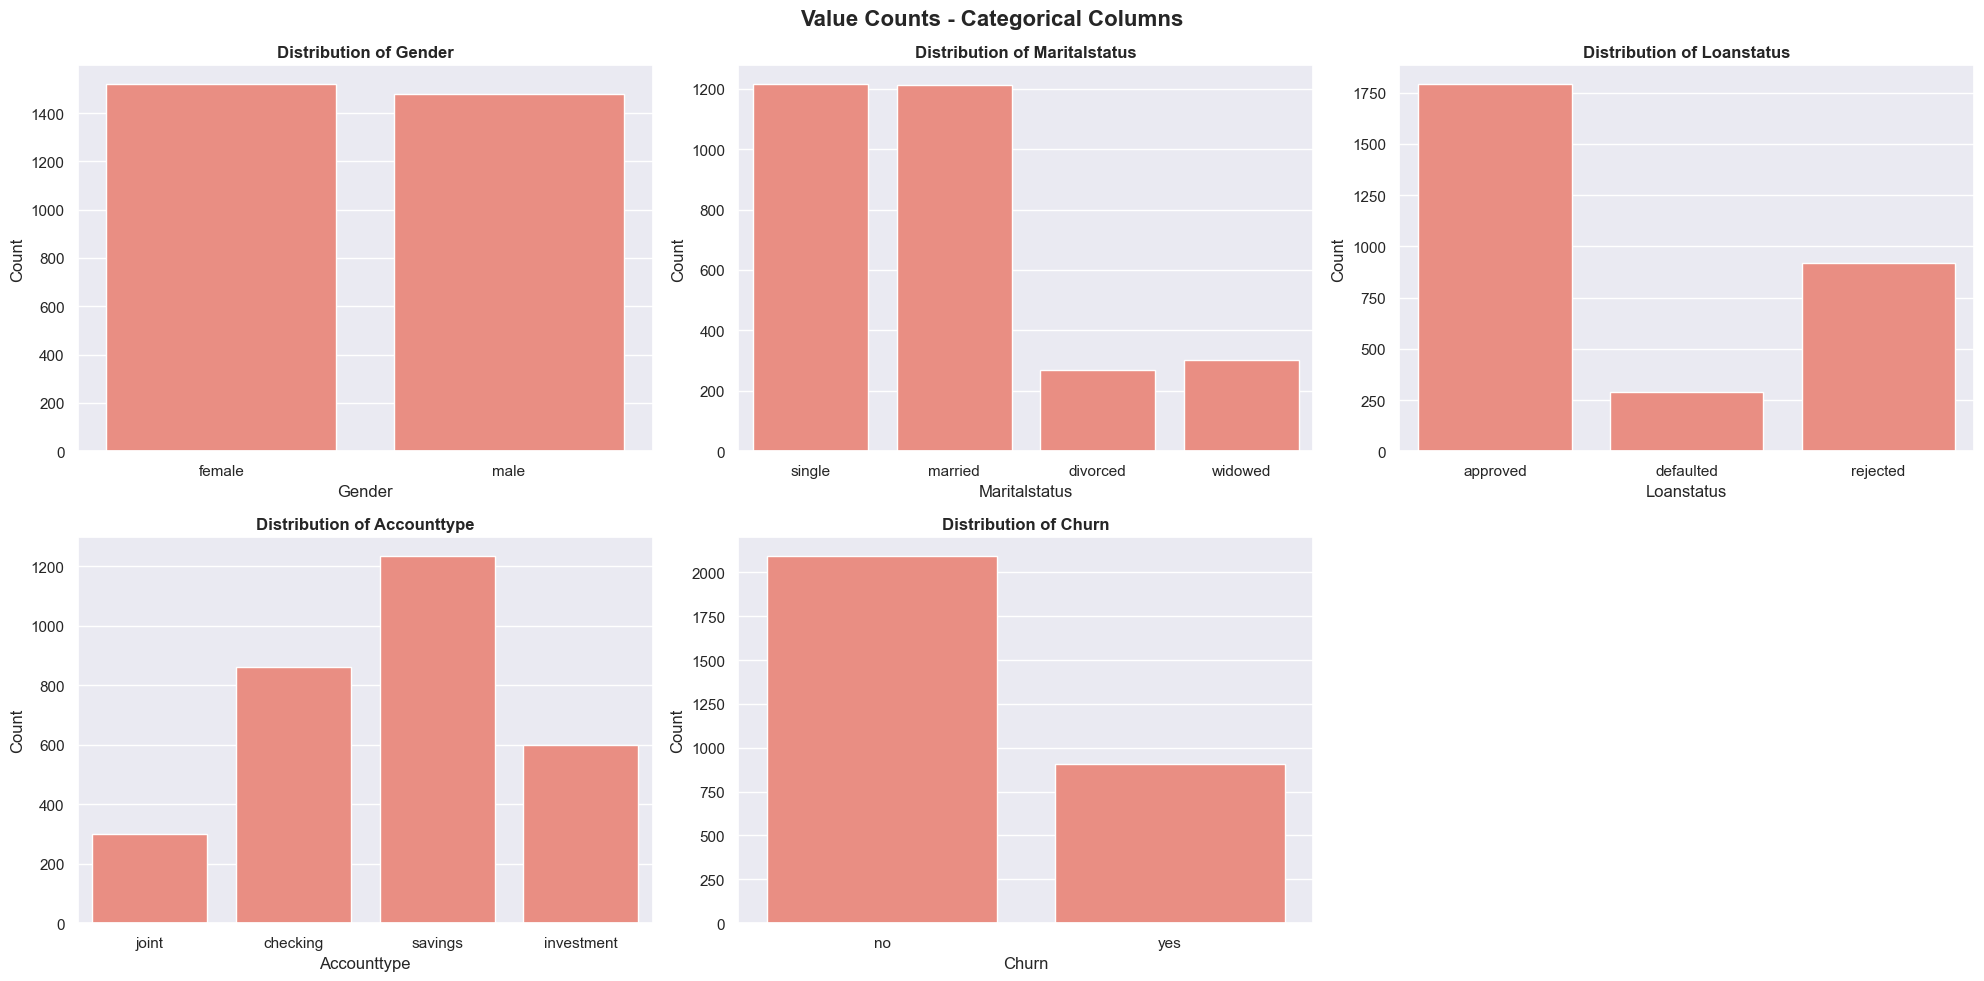

In [161]:
# Bar plots για την κατανομή των categorical columns --> Παίρνουμε μόνο τα str columns
# Seaborn

categorical_cols = bank_customer_analytics.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))  # Φτιάχνω έναν καμβά με 2 γραμμές x 3 στήλες δηλαδή 6 subplots --χωράνε 6 διαγράμματα
axes = axes.flatten() # χρειάζεται για τη seaborn αυτή η εντολή για να γίνει από 2D ---> 1D λίστα για να μπει στη λούπα κάθε φορά στο axes[i]

for i, col in enumerate(categorical_cols):
    sns.countplot(data=bank_customer_analytics, x=col, ax=axes[i], color='salmon') #Πειράματα με χρώματα
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontweight='bold')  #distribution of categorical variables όπως λέει η άσκηση
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False) # Εδώ με το -1 έκρυψα την κενή θέση που δεν χρησιμοποιείται
plt.suptitle('Value Counts - Categorical Columns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Churn Class Distribution

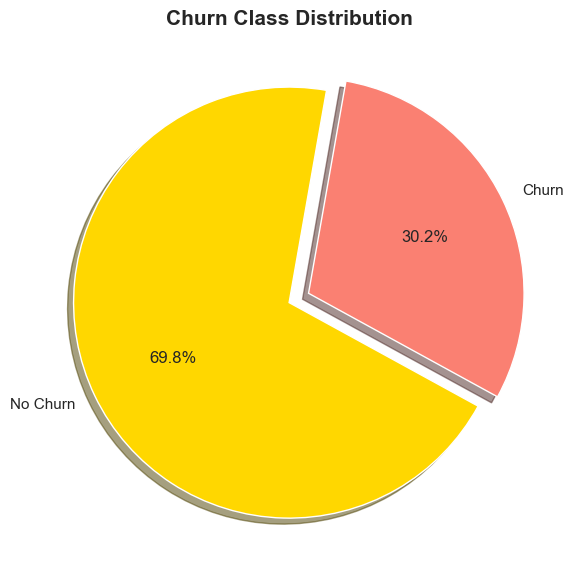

No Churn: 2094 (69.8%)
Churn:    906 (30.2%)

Churn behavior: ~70% stayed, ~30% churned (clients lost).


In [165]:
churn_counts = bank_customer_analytics['churn'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    churn_counts.values,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%', # Με ένα δεκαδικό
    colors=['gold', 'salmon'],
    startangle=80,
    explode=(0, 0.1),
    shadow=True
)
ax.set_title('Churn Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'No Churn: {churn_counts["no"]} ({churn_counts["no"]/len(bank_customer_analytics)*100:.1f}%)')
print(f'Churn:    {churn_counts["yes"]} ({churn_counts["yes"]/len(bank_customer_analytics)*100:.1f}%)')
print()
print('Churn behavior: ~70% stayed, ~30% churned (clients lost).')

### Συμπέρασμα: Έχουμε ένα σπάσιμο σε 70/30. Δεν είναι και τελείως ιδανικό να έχουμε μόνο 30% πελάτες που έφυγαν αλλά είναι επαρκές για την εκπαίδευση ενός μοντέλου classification

### Το ιδανικό θα ήταν 50/50

## 7. Univariate Analysis: 

In [166]:
# Στο βήμα 6 εξετάσαμε τα categorical δηλαδή τα (gender, maritalstatus, loanstatus, accounttype, churn)
# Τώρα θα εξετάσουμε τα numerical δηλαδή τα (age, income, savings, creditscore, loanamount, yearswithbank)

numerical_cols = ['age', 'income', 'savings', 'creditscore', 'loanamount', 'yearswithbank']

# Summary statistics: mean, median, skewness, variance
numerical_data = pd.DataFrame({
    'Mean':     bank_customer_analytics[numerical_cols].mean().round(2),
    'Median':   bank_customer_analytics[numerical_cols].median().round(2),
    'Skewness': bank_customer_analytics[numerical_cols].skew().round(3),
    'Variance': bank_customer_analytics[numerical_cols].var().round(2)
})
print(numerical_data)

# Μας ενδιαφέρει η skewness(ασυμμετρία) εδώ. Age, Income, savings, creditscore,loanamount είναι κοντά στο ο ---> συμμετρία - κανονική κατανομή. 

# yearswithbank = 1,27 --> Ήπια θετική - δεξιά ασυμμετρία
# savings = 3,01 --> Έντονη θετική - δεξιά ασυμμετρία. Μπορεί οι περισσότεροι να έχουν χαμηλές καταθέσεις και κάποιοι λίγοι να έχουν μεγάλες οπότε φουσκώνει ο Mean

# yearswithbank --> διαφορά ανάμεσα στο Mean και στο Median
# savings --> Πολύ αισθητή διαφορά ανάμεσα στο Mean και στο Median

                  Mean   Median  Skewness     Variance
age              39.07    35.00      0.05        92.16
income        68314.67 60000.00      0.07 385117357.34
savings       21463.00 15000.00      3.01 419519804.27
creditscore     694.66   700.00      0.06      4566.94
loanamount    34072.00 30000.00      0.06  95986811.60
yearswithbank     6.85     5.00      1.27        29.29


### Ιστόγραμμα με καμπύλες KDE για numerical columns

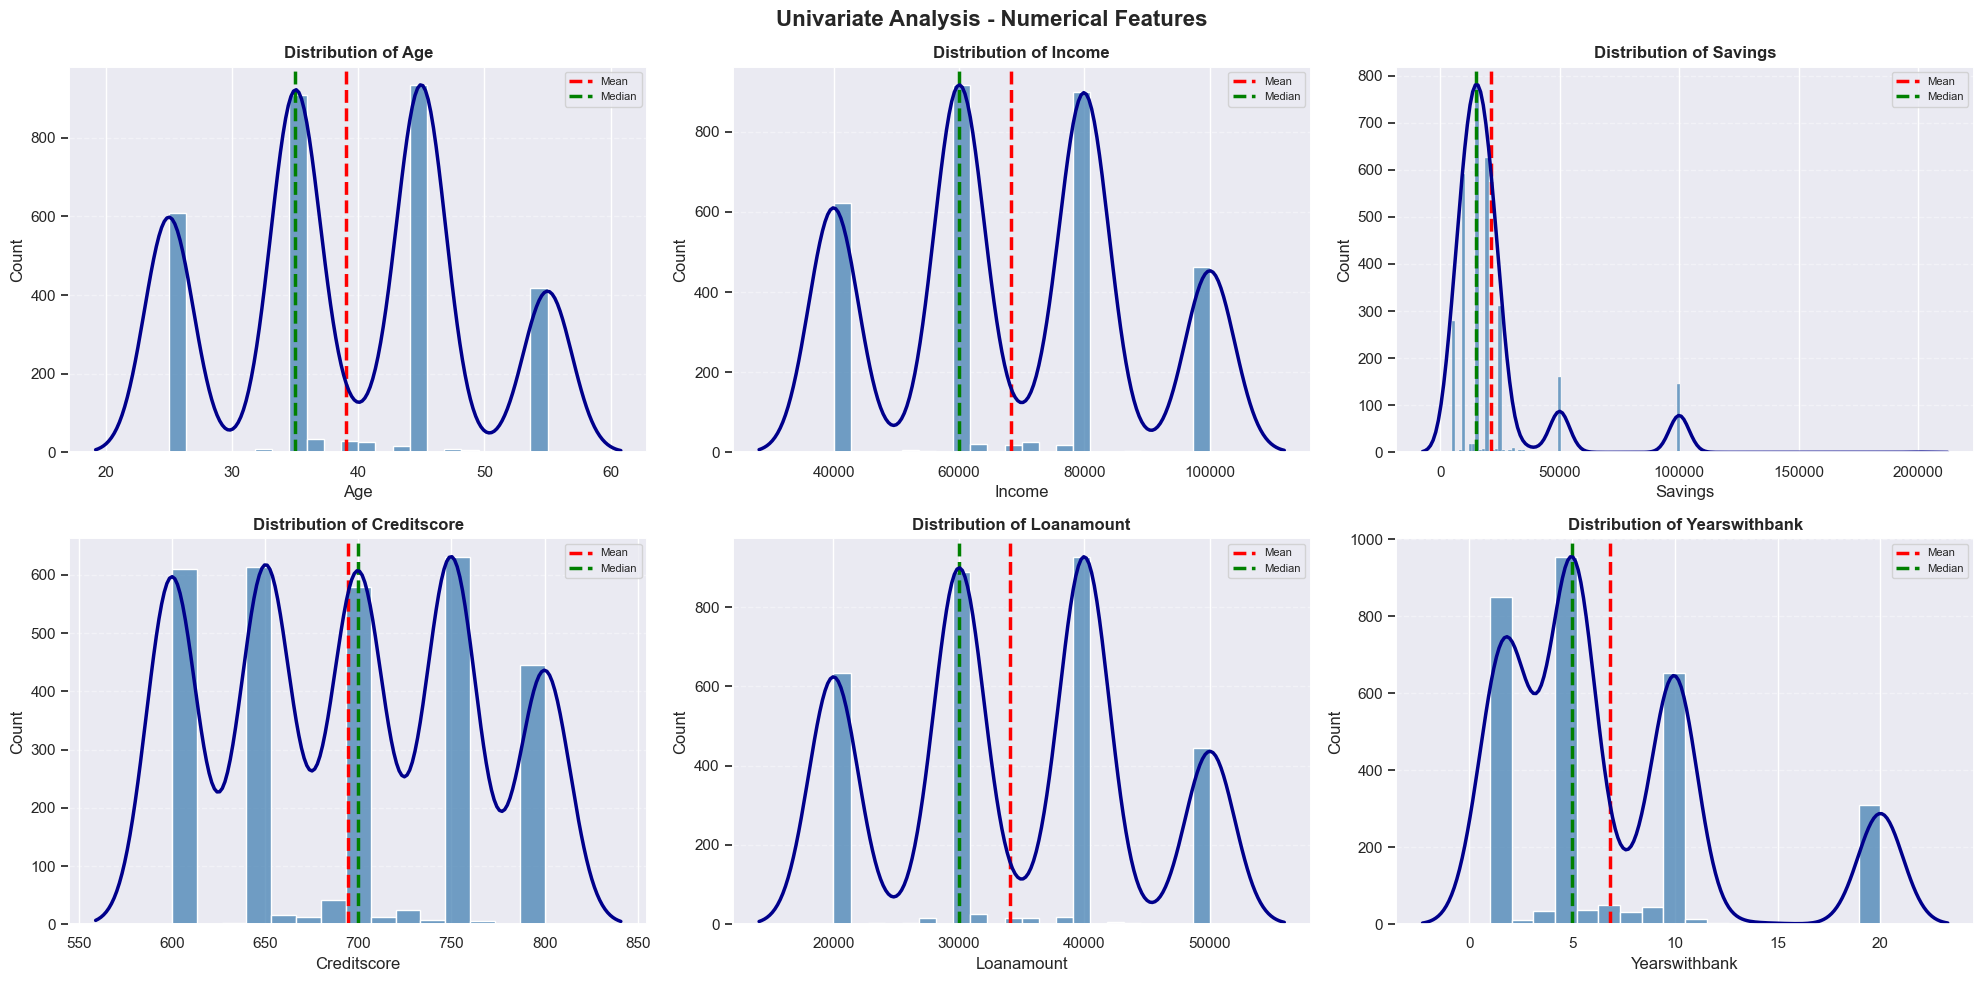

In [169]:
# Ιστόγραμμα με καμπύλες KDE για numerical columns

fig, axes = plt.subplots(2, 3, figsize=(20, 10)) # Φτιάχνω έναν καμβά με 2 γραμμές x 3 στήλες δηλαδή 6 subplots --χωράνε 6 διαγράμματα
axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    # Ξεχωριστά το ιστόγραμμα χωρίς KDE
    sns.histplot(bank_customer_analytics[col], ax=axes[i], kde=False, color='steelblue', edgecolor='white') # kde=False για να το κάνω ξεχωριστά

    # Ξεχωριστά το KDE γιατί δεν με άφηνε να αλλάξω στο χρώμα που θέλω --> χαλούσαν οι καμπύλες τελείως αν το έκανα μαζί με το ιστόγραμμα
    ax2 = axes[i].twinx()
    sns.kdeplot(bank_customer_analytics[col], ax=ax2, color='darkblue', linewidth=2.5)
    ax2.set_ylabel('')
    ax2.set_yticks([])

    axes[i].axvline(bank_customer_analytics[col].mean(),   color='red',   linestyle='--', linewidth=2.5, label='Mean')
    axes[i].axvline(bank_customer_analytics[col].median(), color='green', linestyle='--', linewidth=2.5, label='Median')
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontweight='bold')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.4, linestyle='--')

plt.suptitle('Univariate Analysis - Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Έχουμε 4 peaks στην ηλικία --> 25, 35, 45, 55
# Έχουμε 4 peaks στο εισόδημα --> 40, 60, 80, 100 Κ
# Στις αποταμιεύσεις οι περισσότεροι έχουν έως 25.000 αλλά κάποιοι λίγοι έχουν μεγάλες αποταμιεύσεις οπότε υπάρχει και η μεγάλη δεξιά ουρά
# Στο Creditscore έχουμε πολλά peaks. Mean και Median είναι πολύ κοντά
# Στο δανεισμό έχουμε 4 peaks --> 20, 30, 40, 50 Κ. Mean και Median είναι κοντά
# Φαινομενικά στο δανεισμό η απόσταση μεταξύ Median και Mean είναι μεγαλύτερη από την απόσταση Median και Mean στο Yearswithbank όμως η ασσυμετρία είναι 0,06 ενώ στο yearswithbank είναι 1,27. Εδώ παίζει ρόλο και η κατανομή για την ασσυμετρία. Πολύ δεξιά η ουρά.

### Variance Threshold

In [170]:
# Variance Threshold

from sklearn.feature_selection import VarianceThreshold

threshold = 0.01
selector = VarianceThreshold(threshold=threshold)

# Fit the selector to the data
selected_features = selector.fit_transform(bank_customer_analytics[numerical_cols])

# get_support(indices=True) returns the column index of the features that were kept
print("Features Selected by Variance:", selector.get_support(indices=True))

# See the actual remaining column names
df_filtered = bank_customer_analytics[numerical_cols].iloc[:, selector.get_support()]
print("\nFiltered DataFrame columns:")
print(df_filtered.columns.tolist())

# Κρατάμε όλες τις στήλες - features

Features Selected by Variance: [0 1 2 3 4 5]

Filtered DataFrame columns:
['age', 'income', 'savings', 'creditscore', 'loanamount', 'yearswithbank']


## 8. Outlier Detection: 

### Boxplots για numerical columns

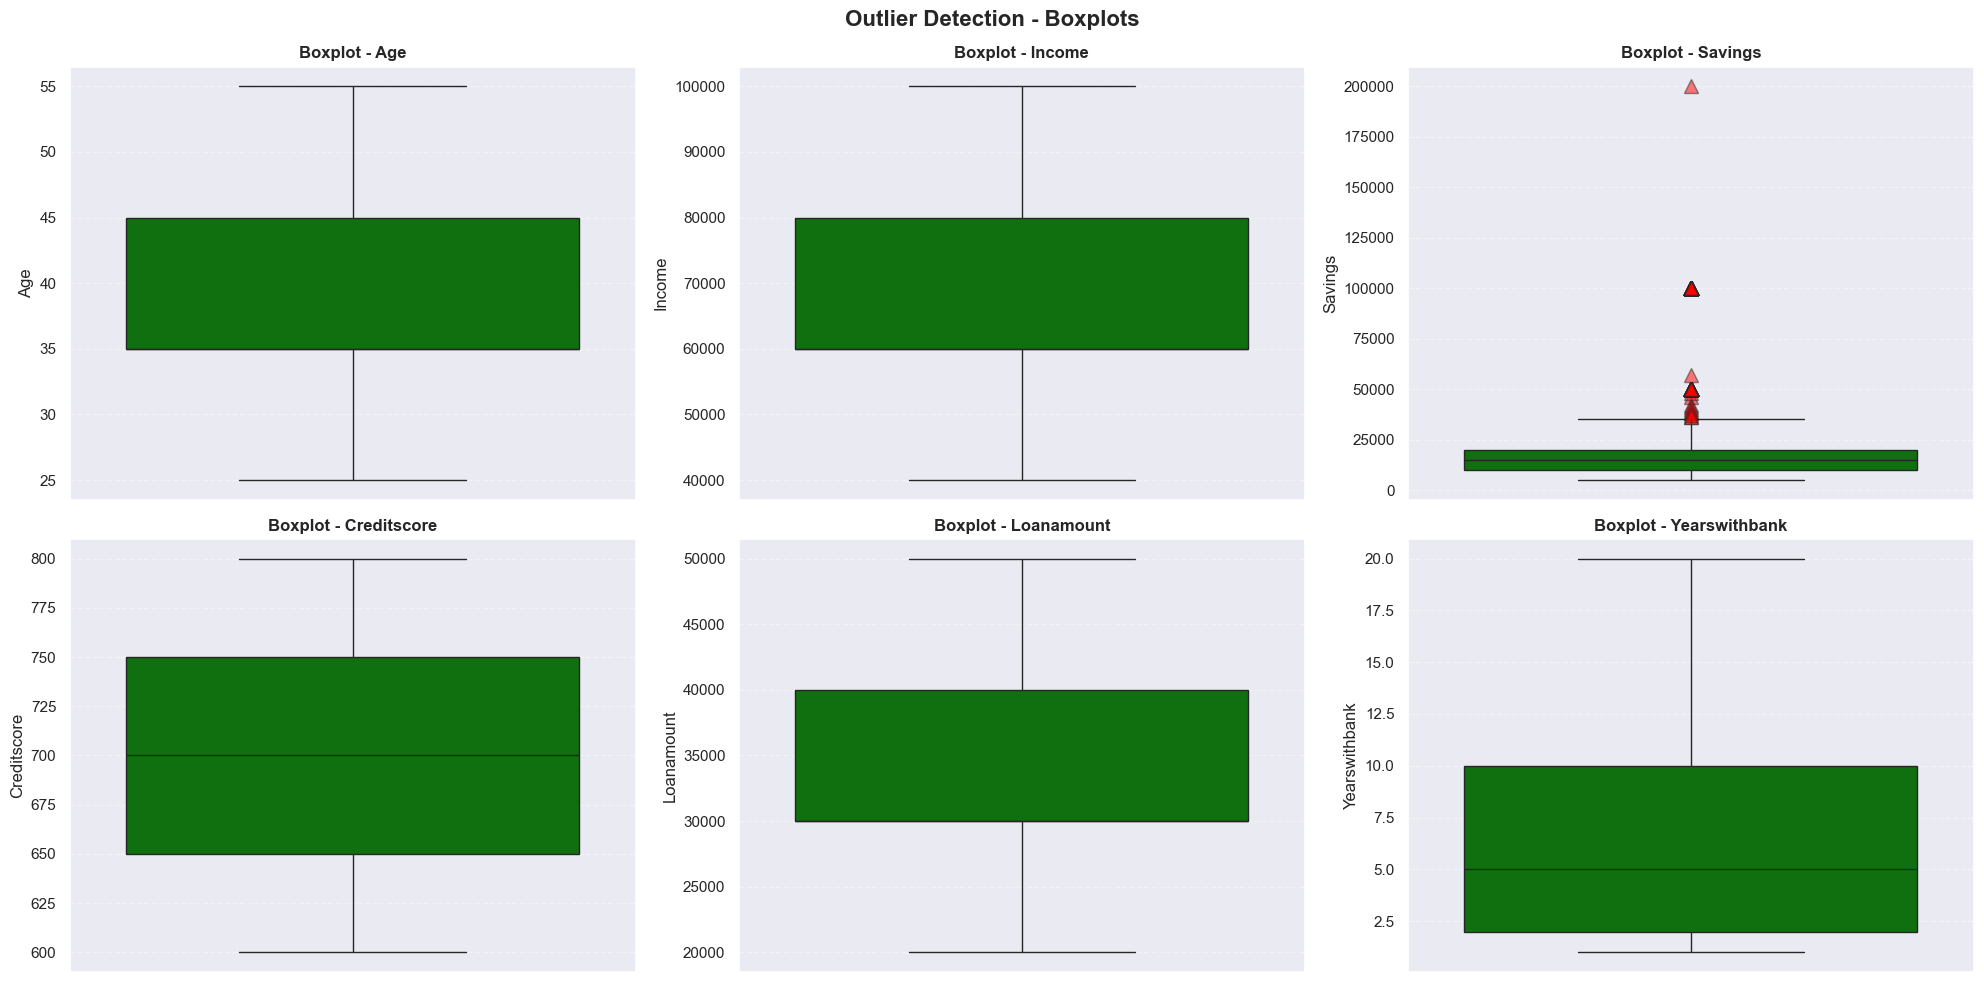

In [171]:
# Boxplots για numerical columns ---> Αναζήτηση Outlier(Σε όλο το dataset 3.000 γραμμές ανά numerical feature)

fig, axes = plt.subplots(2, 3, figsize=(20, 10)) # Φτιάχνω έναν καμβά με 2 γραμμές x 3 στήλες δηλαδή 6 subplots --χωράνε 6 διαγράμματα
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=bank_customer_analytics[col], ax=axes[i], color='green',flierprops=dict(marker='^', markerfacecolor='red', markersize=10, alpha=0.5))
    axes[i].set_title(f'Boxplot - {col.capitalize()}', fontweight='bold')
    axes[i].set_ylabel(col.capitalize())
    axes[i].grid(axis='y', alpha=0.4, linestyle='--')

plt.suptitle('Outlier Detection - Boxplots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### IQR Calc from Boxplots

In [172]:
# Age, Income, Creditscore, Loanamount, δεν έχουμε outliers
# Yearswithbank φαίνεται πως ούτε εκεί έχουμε


# Savings: Φαίνεται πως έχουμε κάποια outliers. Ξεφεύγει από το q3, και από το upper whisker
# -------> Q1, Q3, Median, IQR

Q1_savings     = bank_customer_analytics['savings'].quantile(0.25)
Q3_savings     = bank_customer_analytics['savings'].quantile(0.75)
median_savings = bank_customer_analytics['savings'].median()
IQR_savings    = Q3_savings - Q1_savings

print(f'Q1 (bottom of box): {Q1_savings}')
print(f'Median:             {median_savings}')
print(f'Q3 (top of box):    {Q3_savings}')
print(f'IQR:                {IQR_savings}')
print(f'Lower whisker:      {Q1_savings - 1.5 * IQR_savings}')
print(f'Upper whisker:      {Q3_savings + 1.5 * IQR_savings}')



Q1 (bottom of box): 10000.0
Median:             15000.0
Q3 (top of box):    20000.0
IQR:                10000.0
Lower whisker:      -5000.0
Upper whisker:      35000.0


### IQR Calc from Boxplots --> Outlier count

In [173]:
# Μεταράω τα outliers ανά στήλη με IQR method

print('Outlier count per column (IQR method):')
print('-----------------------------------------------------------')
for col in numerical_cols:
    Q1  = bank_customer_analytics[col].quantile(0.25)
    Q3  = bank_customer_analytics[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = bank_customer_analytics[(bank_customer_analytics[col] < lower) | (bank_customer_analytics[col] > upper)]
    print(f'{col}: {len(outliers)} outliers  (lower: {lower:.2f}, upper: {upper:.2f})')

    # Yearswithbank Τελικά δεν έχουμε
    # Savings, εδώ έχουμε αρκετούς outliers ---> 317/3000 = 10,6% Μεγάλο ποσοστό πλουσίων με πολλές καταθέσεις. Δεν μπορώ να τους βγάλω από το δείγμα. Η τράπεζα ίσα ίσα που ενδιαφέρεται για αυτούς

Outlier count per column (IQR method):
-----------------------------------------------------------
age: 0 outliers  (lower: 20.00, upper: 60.00)
income: 0 outliers  (lower: 30000.00, upper: 110000.00)
savings: 317 outliers  (lower: -5000.00, upper: 35000.00)
creditscore: 0 outliers  (lower: 500.00, upper: 900.00)
loanamount: 0 outliers  (lower: 15000.00, upper: 55000.00)
yearswithbank: 0 outliers  (lower: -10.00, upper: 22.00)


### Scatterplot για numerical columns ---> Αναζήτηση Outlier ---> Πρώτη Ομάδα Scatter_pairs

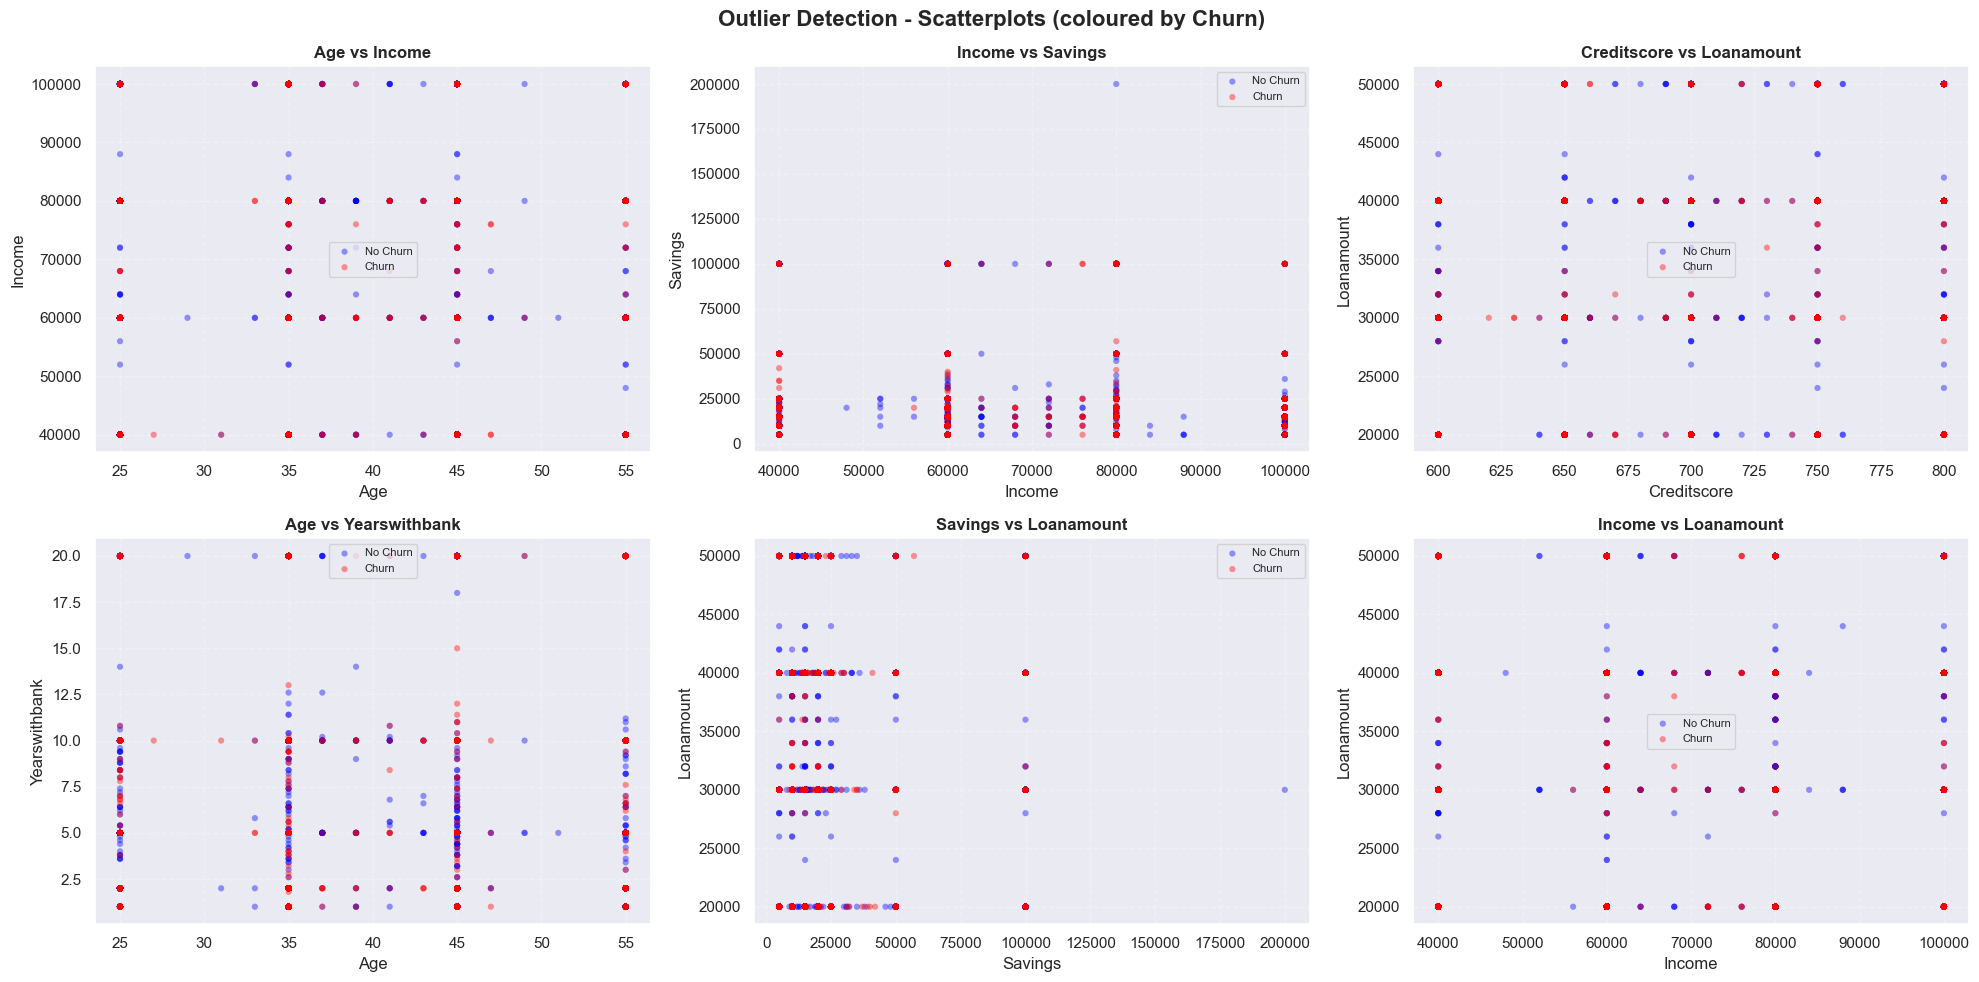

In [174]:
# Scatterplot για numerical columns ---> Αναζήτηση Outlier ---> Πρώτη Ομάδα Scatter_pairs

scatter_pairs = [
    ('age',    'income'),
    ('income', 'savings'),
    ('creditscore', 'loanamount'),
    ('age',    'yearswithbank'),
    ('savings','loanamount'),
    ('income', 'loanamount')
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(scatter_pairs):
    for churn_val, color, label in [('no', 'blue', 'No Churn'), ('yes', 'red', 'Churn')]:
        subset = bank_customer_analytics[bank_customer_analytics['churn'] == churn_val]
        axes[i].scatter(subset[x_col], subset[y_col],
                        alpha=0.4, s=20, color=color, label=label, edgecolors='none')
    axes[i].set_title(f'{x_col.capitalize()} vs {y_col.capitalize()}', fontweight='bold')
    axes[i].set_xlabel(x_col.capitalize())
    axes[i].set_ylabel(y_col.capitalize())
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3, linestyle='--')

plt.suptitle('Outlier Detection - Scatterplots (coloured by Churn)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Πρώτη Ομάδα

# ('age', 'income') ---> Βλέπω κυρίως τιμές σε ηλικίες 25, 35, 45, 55 με εισόδημα αντίστοιχα 40, 60, 80, 100 Κ. Δεν παρατηρώ κάποιο pattern στο churn. Έρχονται και φεύγουν σε όλους τους συνδιασμούς 'age', 'income'. 
# ('income', 'savings') ---> Η μεγαλύτερη συγκέντρωση πελατών βρίσκεται στις αποταμιεύσεις 0 -50Κ ανεξαρτήτως εισοδήματος. Υψηλές αποταμιεύσεις βλέπουμε σε όλα τα εισοδήματα (40 - 100Κ). Βλέπουμε και τα outliers στα εισοδήματα 100, 200Κ. Δεν παρατηρώ κάποιο pattern στο churn.
# ('creditscore', 'loanamount') ---> Μείγμα churn και No churn σαν ένα πλέγμα. Δεν βλέπω σχέση ή μοτίβο μεταξύ ('creditscore', 'loanamount')

#'yearswithbank' ---> Εδώ γέμισε ο ΚΝΝ
# ('age', 'yearswithbank') ---> Βλέπω κυρίως τιμές σε ηλικίες 25, 35, 45, 55. Πελάτες όλων των ηλικιών μπορεί να έχουν οποιοδήποτε χρόνο παραμονής/συνεργασίας στην τράπεζα. Ένας 25 ετών μπορεί να έχει 20 έτη συνεργασία σε τράπεζα? 
# yearswithbank: 0 outliers  (lower: -10.00, upper: 22.00) --> Τα 20 έτη όμως δεν είναι outlier όπως είδα με το Boxplot --> Στα 5 του άνοιξε λογαριασμό? ίσως επειδή είναι dataset για εκπαιδευτικούς λόγους

# ('savings','loanamount') ---> Κυρίως παίρνουν δάνεια αυτοί που έχουν αποταμιεύσεις από 0 - 50Κ. Βλέπω Outliers για savings από 100Κ (έφυγαν οι πιο πολλοί, ίσως για καλύτερες ευακαιρίες) και 200Κ (αυτός έμεινε). Δεν βλέπω σχέση μεταξύ 'savings','loanamount'
# ('income', 'loanamount') ---> Μείγμα churn και No churn σαν ένα πλέγμα. Δεν βλέπω κάποιο μοτίβο για No churn ή σχέση μεταξύ 'income', 'loanamount'

# Δεν υπάρχει κάποιο pattern μεταξύ churn και no churn στα 6 αυτά διαγράμματα. Δεν υπαρχει κάποια διάκριση μεταξύ στους churners αυτούς που φεύγουν δηλαδή και σε αυτούς που μένουν στην τράπεζα
# Στα savings που κοιτούσα και πριν βλέπω ότι και αυτοί που φεύγουν από την τράπεζα και αυτοί που μένουν μπορεί να έχουν εξίσου μεγάλες αποταμιεύσεις


### Scatterplot για numerical columns ---> Αναζήτηση Outlier ---> Δεύτερη Ομάδα Scatter_pairs

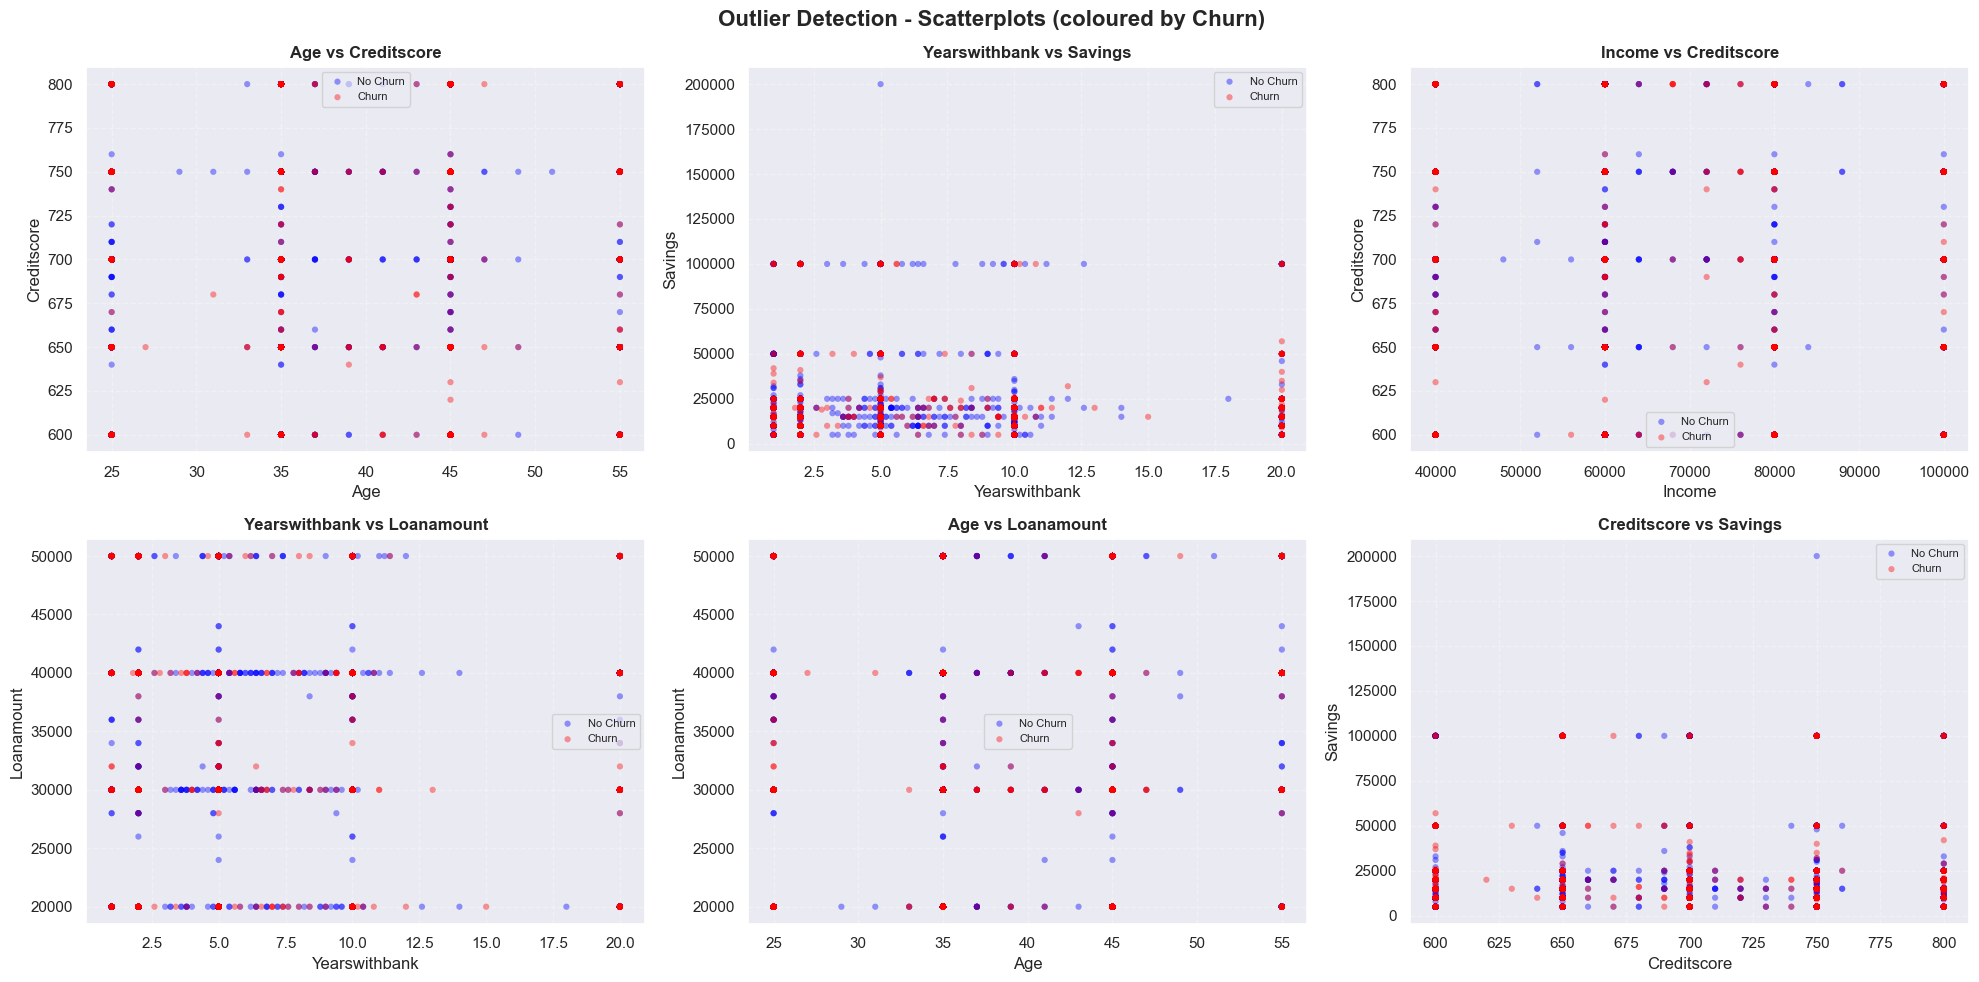

In [175]:
# Scatterplot για numerical columns ---> Αναζήτηση Outlier ---> Δεύτερη Ομάδα Scatter_pairs

scatter_pairs_2 = [
    ('age',          'creditscore'),
    ('yearswithbank','savings'),
    ('income',       'creditscore'),
    ('yearswithbank','loanamount'),
    ('age',          'loanamount'),
    ('creditscore',  'savings')
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(scatter_pairs_2):
    for churn_val, color, label in [('no', 'blue', 'No Churn'), ('yes', 'red', 'Churn')]:
        subset = bank_customer_analytics[bank_customer_analytics['churn'] == churn_val]
        axes[i].scatter(subset[x_col], subset[y_col],
                        alpha=0.4, s=20, color=color, label=label, edgecolors='none')
    axes[i].set_title(f'{x_col.capitalize()} vs {y_col.capitalize()}', fontweight='bold')
    axes[i].set_xlabel(x_col.capitalize())
    axes[i].set_ylabel(y_col.capitalize())
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3, linestyle='--')

plt.suptitle('Outlier Detection - Scatterplots (coloured by Churn)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Δεύτερη Ομάδα

# ('age','creditscore') ---> Μείγμα churn και No churn σαν ένα πλέγμα. Δεν βλέπω σχέση ή μοτίβο μεταξύ ('age','creditscore'). Μεγαλύτερη ηλικία δεν σημαίνει και καλύτερο creditscore
# ('yearswithbank','savings') ---> Βλέπω Outliers για savings από 100Κ και 200K.Υψηλές αποταμιεύσεις δεν έχουν σχέση με το πόσα χρόνια είναι κάποιος σε μία τράπεζα
# ('income','creditscore') ---> Μείγμα churn και No churn σαν ένα πλέγμα. Δεν βλέπω σχέση ή μοτίβο μεταξύ ('income','creditscore'). Μεγαλύτερο εισόδημα δεν σημαίνει και καλύτερο creditscore
# ('yearswithbank','loanamount') ---> #'yearswithbank' ---> Εδώ γέμισε ο ΚΝΝ. Σε όλα τα ποσά δανείων υπάρχουν πελάτες 20 ετών
# ('age', 'loanamount') ---> Μείγμα churn και No churn σαν ένα πλέγμα. Μεγαλύτερης ηλικίας πελάτες δεν σημαίνει ότι θα πάρουν και μεγαλύτερα ποσά δανείων
# ('creditscore','savings') ---> Ομαδοποίηση πελατών με αποταμιεύσεις από 0 - 25Κ. outliers για 100, 200Κ.---> Outliers είναι και churned και No churned. Μεγάλες αποταμιεύσεις έχουν πελάτες και σε μικρά και σε μεγάλα credit score και το ανάποδο. 

## Συμπέρασμα: Εξετάσαμε 12 συνδιασμούς χαρακτηριστικών και κανένα ζεύγος από μόνο του δεν μπορεί να διαχωρίσει τους πελάτες που έφυγαν από αυτούς που έμειναν. Μοναδικό στοιχείο αποτελούν οι outliers στα savings: 317 outliers  (lower: -5000.00, upper: 35000.00)

## 9. Bivariate & Multivariate Analysis:

### Boxplots για numerical columns ---> Αναζήτηση Outlier(Σε όλο το dataset 3.000 γραμμές ανά numerical feature ---> Αλλά χωρισμένο σε churned και No churned)

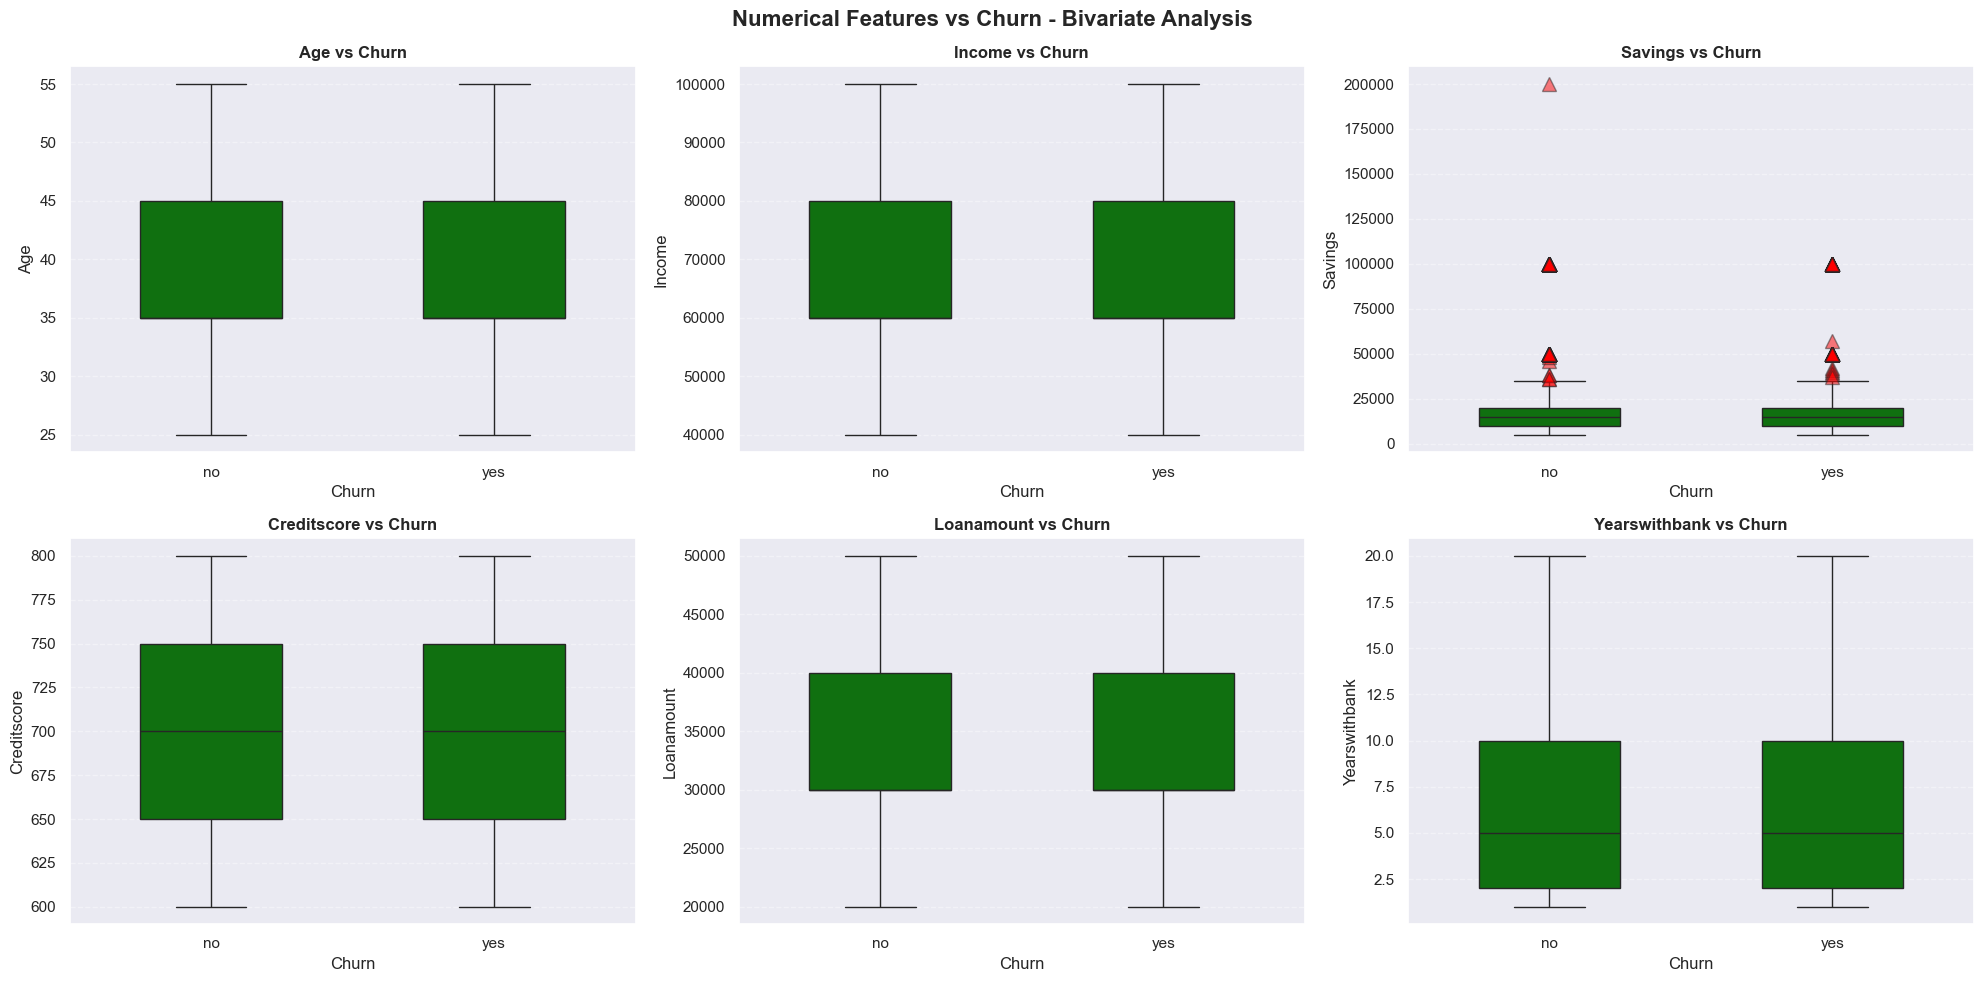

In [176]:
# Boxplots για numerical columns ---> Αναζήτηση Outlier(Σε όλο το dataset 3.000 γραμμές ανά numerical feature ---> Αλλά χωρισμένο σε churned και No churned)

fig, axes = plt.subplots(2, 3, figsize=(20, 10)) # Φτιάχνω έναν καμβά με 2 γραμμές x 3 στήλες δηλαδή 6 subplots --χωράνε 6 διαγράμματα
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=bank_customer_analytics, x='churn', y=col, ax=axes[i],color='green',width=0.5,flierprops=dict(marker='^', markerfacecolor='red', markersize=10, alpha=0.5))
    axes[i].set_title(f'{col.capitalize()} vs Churn', fontweight='bold')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col.capitalize())
    axes[i].grid(axis='y', alpha=0.4, linestyle='--')

plt.suptitle('Numerical Features vs Churn - Bivariate Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Κανένα από αυτα τα feature δεν δείχνει κάποια συσχέτιση μεταξύ churned και No churned. Όλα τα boxplots είναι σχεδόν όμοια μεταξύ τους.
# Έχουμε τους outliers στις αποταμιεύσεις. Υψηλές αποταμιεύσεις έχουν τόσο οι churned όσο και οι No churned.

### Categorical Features vs Churn (Grouped Bar Plots) ---> Γκρουπ κατηγορικά χαρακτηριστικά με churned και No churned

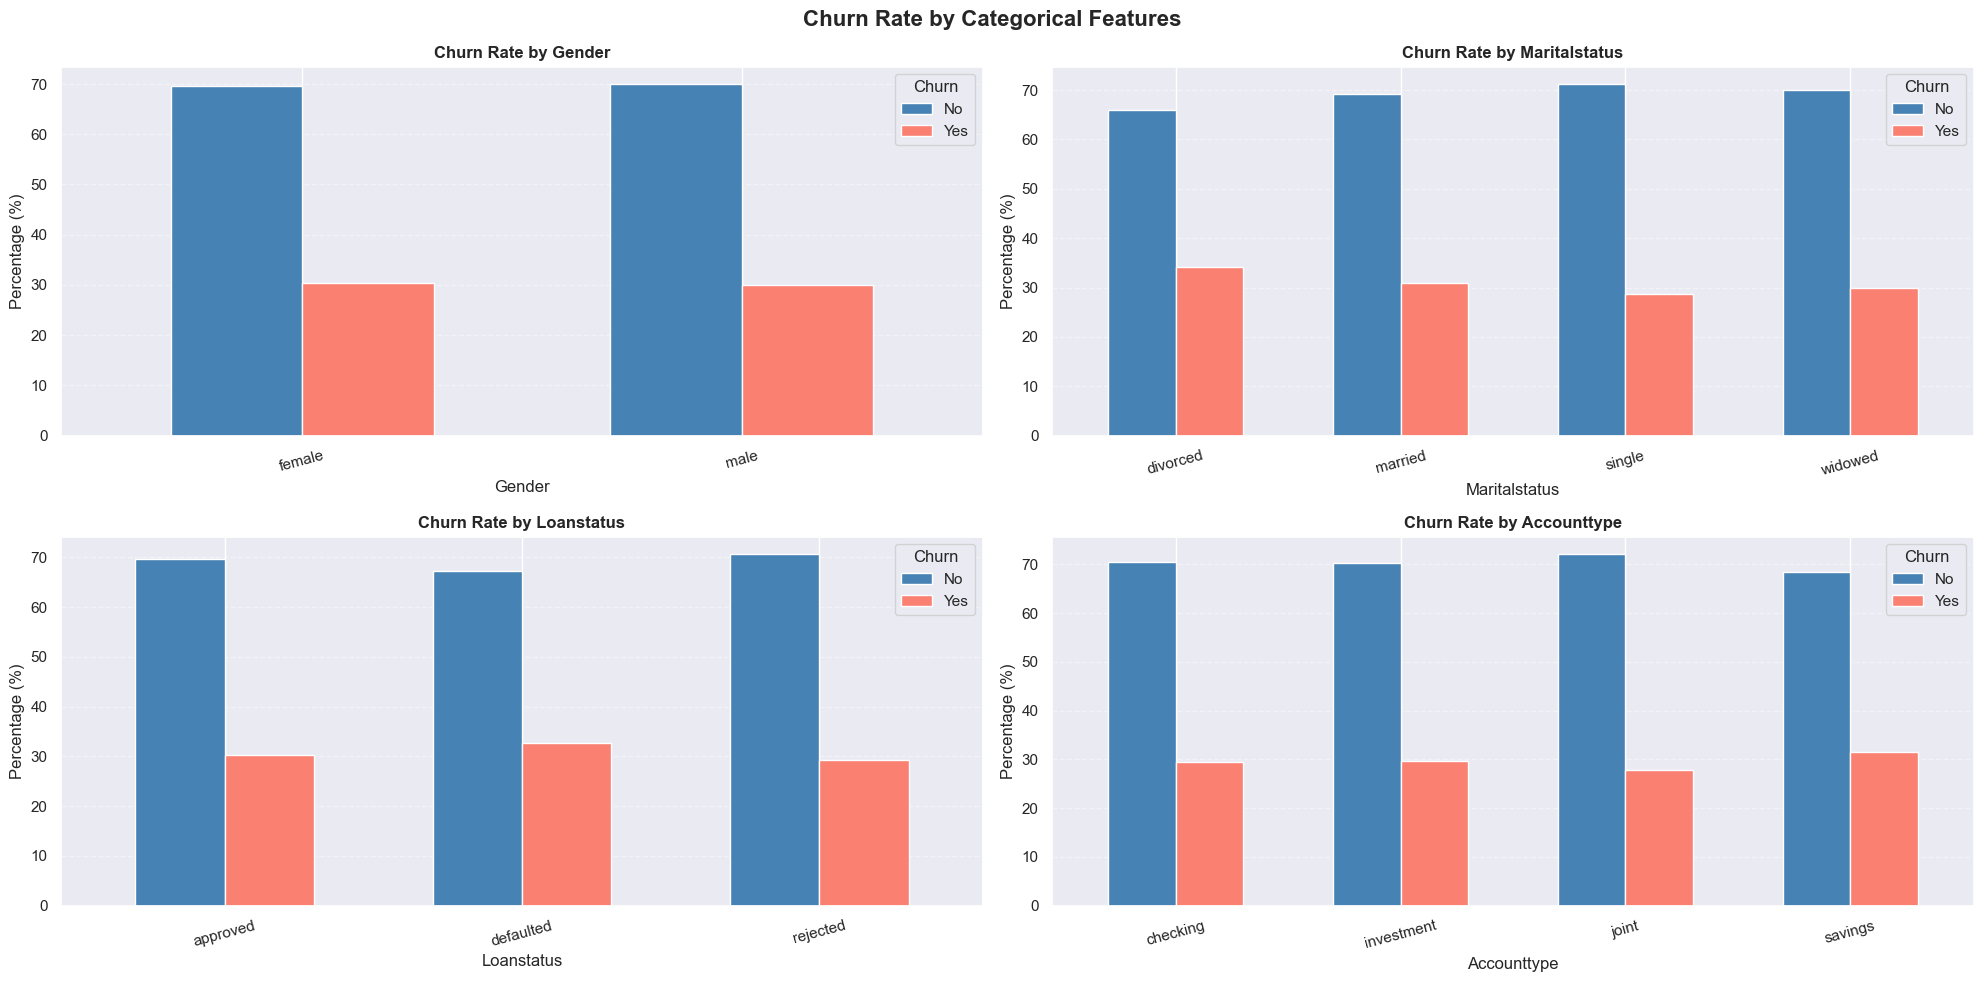

In [177]:
# Categorical Features vs Churn (Grouped Bar Plots) ---> Γκρουπ κατηγορικά χαρακτηριστικά με churned και No churned

cat_features = ['gender', 'maritalstatus', 'loanstatus', 'accounttype']

fig, axes = plt.subplots(2, 2, figsize=(20, 10)) # Φτιάχνω έναν καμβά με 2 γραμμές x 2 στήλες δηλαδή 4 subplots --χωράνε 4 διαγράμματα
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = bank_customer_analytics.groupby([col, 'churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i],color=['steelblue', 'salmon'],edgecolor='white', width=0.6)
    axes[i].set_title(f'Churn Rate by {col.capitalize()}', fontweight='bold')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Churn', labels=['No', 'Yes'])
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.4, linestyle='--')

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Σε κανένα κατηγορικό χαρακτηριστικό δεν βλέπω σημαντική διαφορά μεταξύ churned και No churned.
# Σε όλες τις ομάδες 70% μένουν και 30% φεύγουν
# Οι defaulted πελάτες (χρεοκοπημένοι) φεύγουν λίγο παραπάνω από την τράπεζα από ότι οι άλλες κατηγορίες χαρακτηριστικών

### Pairplot - All Numerical features (σε σχέση με Churn)

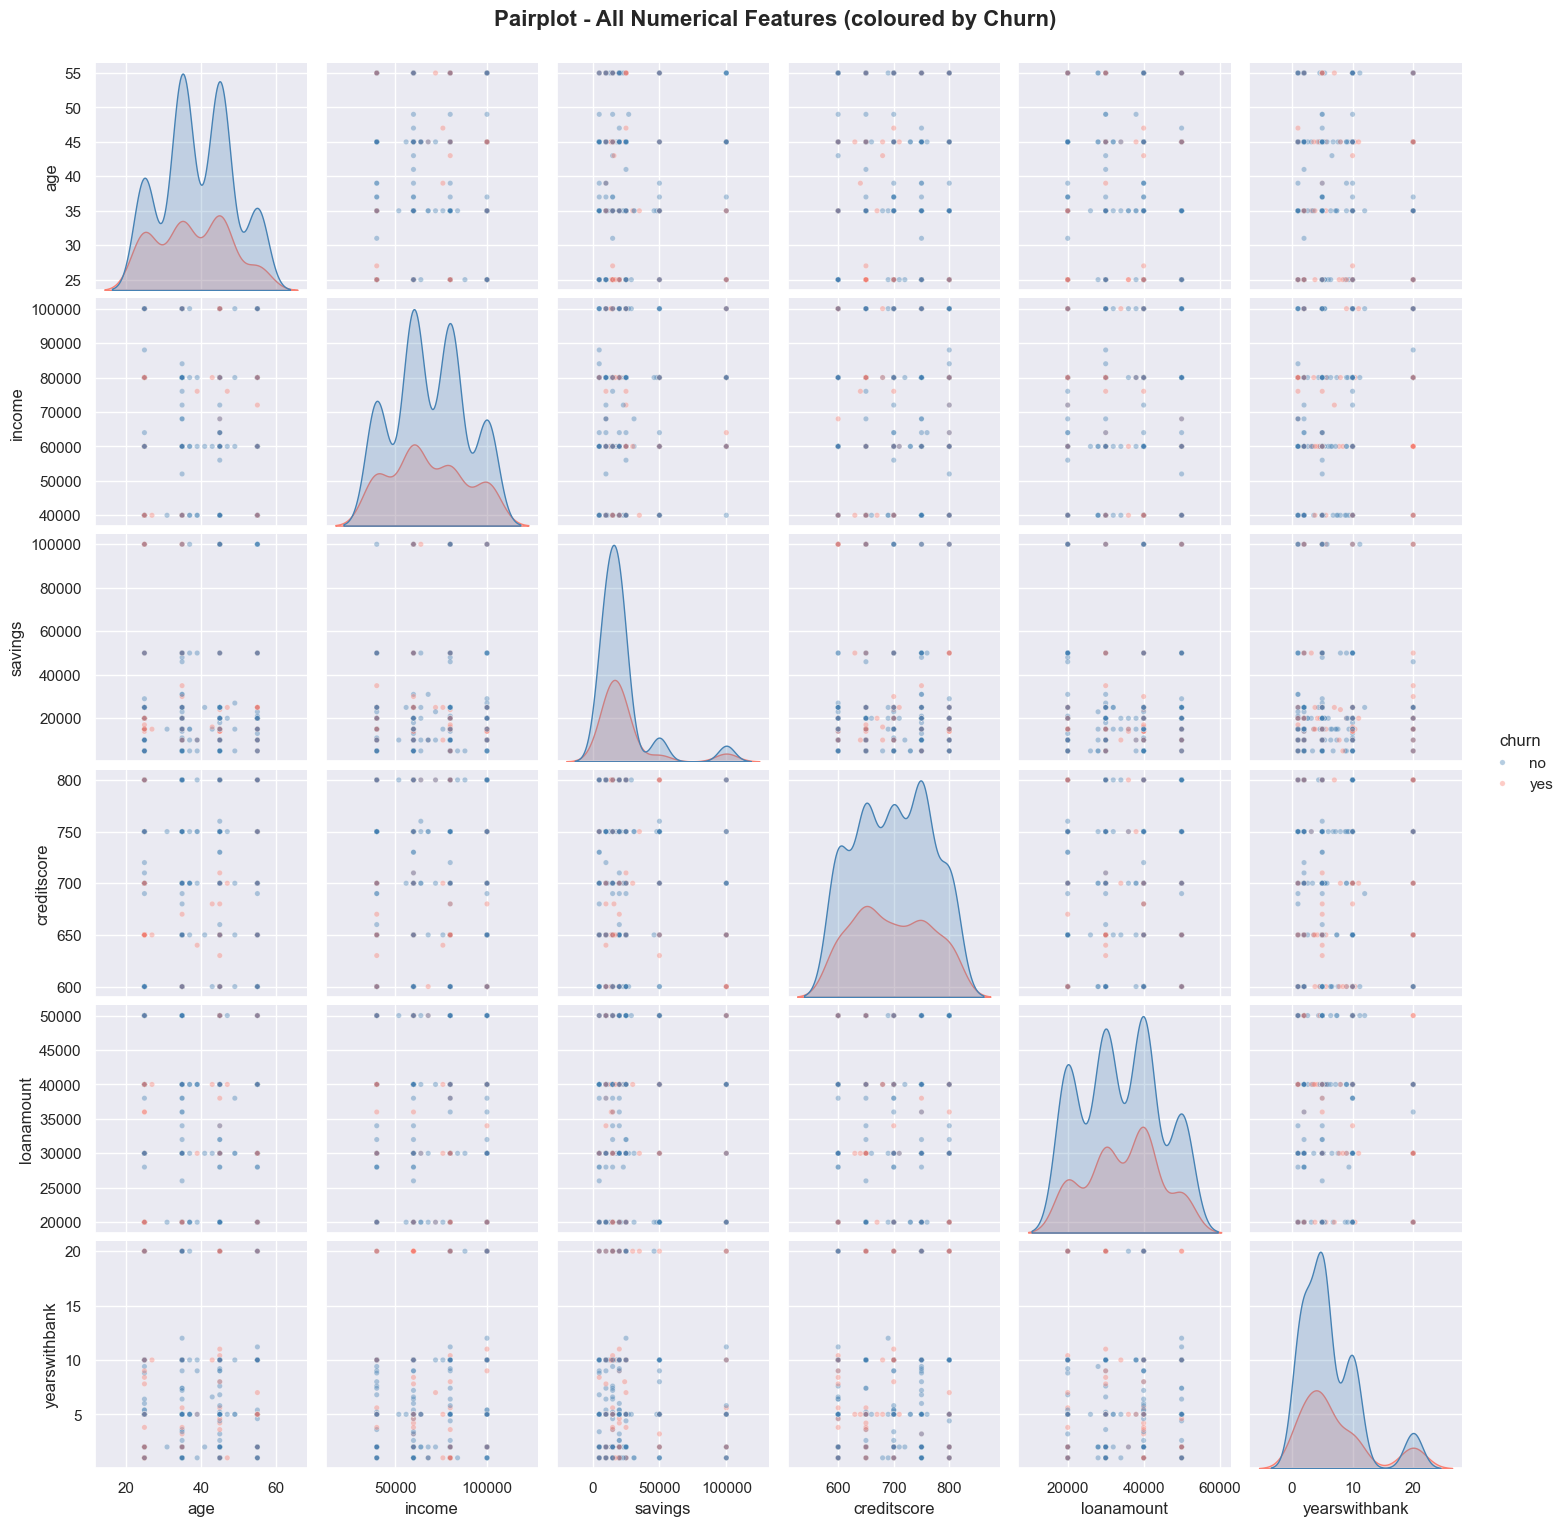

In [178]:
# Pairplot

# Βάζω ένα δείγμα με 500
bank_customer_analytics_sample = bank_customer_analytics.sample(500, random_state=42)

Graph = sns.pairplot(
    bank_customer_analytics_sample[numerical_cols + ['churn']],
    hue='churn',
    palette={'no': 'steelblue', 'yes': 'salmon'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde',
    height=2.5,        # Ύψος κάθε subplot
    aspect=1           # Αναλογία πλάτους/ύψους
)

Graph.figure.suptitle('Pairplot - All Numerical Features (coloured by Churn)',
                   fontsize=16, fontweight='bold', y=1.02)
plt.show()


In [ ]:
# Στην διαγώνιο αποτυπώνονται τα numerical features ως προς churned και No churned
# Κατανομή Age churned και No churned σχεδόν ίδια --> Η Ηλικία δεν σχετίζεται με κανένα άλλο numerical feature ως προς churned και No churned
# Κατανομή Income churned και No churned σχεδόν ίδια --> Το εισόδημα δεν σχετίζεται με κανένα άλλο numerical feature ως προς churned και No churned
# Κατανομή Savings churned και No churned σχεδόν ίδια --> Οι  αποταμιεύσεις δεν σχετίζονται με κανένα άλλο numerical feature ως προς churned και No churned. --> Έχουμε κάποια Outlier που τα είδαμε και πιο πάνω --> # savings = 3,01 --> Έντονη θετική - δεξιά ασυμμετρία βλέπε Βήμα 7
# Κατανομή Creditscore churned και No churned σχεδόν ίδια --> Το Creditscore δεν σχετίζεται με κανένα άλλο numerical feature ως προς churned και No churned
# Κατανομή loanamount churned και No churned σχεδόν ίδια --> Το ποσό δανεισμού δεν σχετίζεται με κανένα άλλο numerical feature ως προς churned και No churned

# Κατανομή yearswithbank churned και No churned --> Και οι δύο καμπύλες έχουν ένα peak μέχρι τα 5 έτη. Στα 1-5 έτη οι churned φαίνεται ότι αποχωρούν περισσότερο. Δηλαδή οι νέοι πελάτες της τράπεζας τείνουν να αποχωρήσουν και πιο γρήγορα.
# Όσο αυξάνονται τα έτη παραμονής στην τράπεζα οι πελάτες αποχωρούν λιγότερο

## 10.Correlation Analysis: 

### Μέθοδος 1: Pearson Correlation - Γραμμική συχέστιση

In [180]:
from sklearn.preprocessing import LabelEncoder

# Κάνω ένα copy του αρχικού dataframe γιατί θα μετατρέψω τα κατηγορικά features σε αριθμούς για να γίνει το correlation
bank_customer_analytics_encoded = bank_customer_analytics.copy()

categorical_cols_enc = LabelEncoder()
categorical_cols = ['gender', 'maritalstatus', 'loanstatus', 'accounttype', 'churn']  # Έχω 5 κατηγορικά features

for col in categorical_cols:
    bank_customer_analytics_encoded[col] = categorical_cols_enc.fit_transform(bank_customer_analytics_encoded[col])

print('Encoding complete. Churn: 0 = no, 1 = yes') # Όλα τα str στα κατηγορικά columns μετατρέπονται αλφαβητικά σε αριθμούς πχ. gender: female, male --> Γίνεται 0, 1. Το ίδιο και στο Churn: No, Yes --> 0, 1
bank_customer_analytics_encoded.head()

# yearswithbank --> Γέμισε ο ΚΝΝ για αυτό βλέπω 6,40, 5,60 κλπ.


Encoding complete. Churn: 0 = no, 1 = yes


,age,gender,maritalstatus,income,savings,creditscore,loanamount,loanstatus,accounttype,yearswithbank,churn
0,25.00,0,2,80000.00,15000.00,600.00,50000.00,0,2,6.40,0
1,35.00,1,2,40000.00,5000.00,700.00,40000.00,0,2,10.00,0
2,35.00,0,2,100000.00,20000.00,800.00,50000.00,1,0,10.00,0
3,45.00,1,1,80000.00,20000.00,750.00,30000.00,0,0,5.60,0
4,45.00,1,1,40000.00,25000.00,750.00,20000.00,2,0,2.00,1


In [182]:
correlation_matrix = bank_customer_analytics_encoded.corr()
print(correlation_matrix.round(2))

                age  gender  maritalstatus  income  savings  creditscore  \
age            1.00    0.01          -0.01    0.01    -0.02        -0.03   
gender         0.01    1.00           0.00    0.02    -0.02        -0.01   
maritalstatus -0.01    0.00           1.00    0.01     0.01         0.01   
income         0.01    0.02           0.01    1.00    -0.02         0.02   
savings       -0.02   -0.02           0.01   -0.02     1.00        -0.01   
creditscore   -0.03   -0.01           0.01    0.02    -0.01         1.00   
loanamount     0.02    0.01          -0.00    0.04    -0.03        -0.02   
loanstatus     0.05   -0.00           0.05   -0.02     0.02         0.01   
accounttype    0.02   -0.02           0.02    0.02     0.00        -0.01   
yearswithbank  0.03    0.00          -0.01    0.03     0.02        -0.02   
churn         -0.01   -0.00          -0.03   -0.01     0.00         0.03   

               loanamount  loanstatus  accounttype  yearswithbank  churn  
age         

### Οι τιμές μας κυμαίνονται από -0.03 έως 0.05. Κανένα feature δεν έχει κάποια γραμμική σχέση με άλλο feature ή το churn

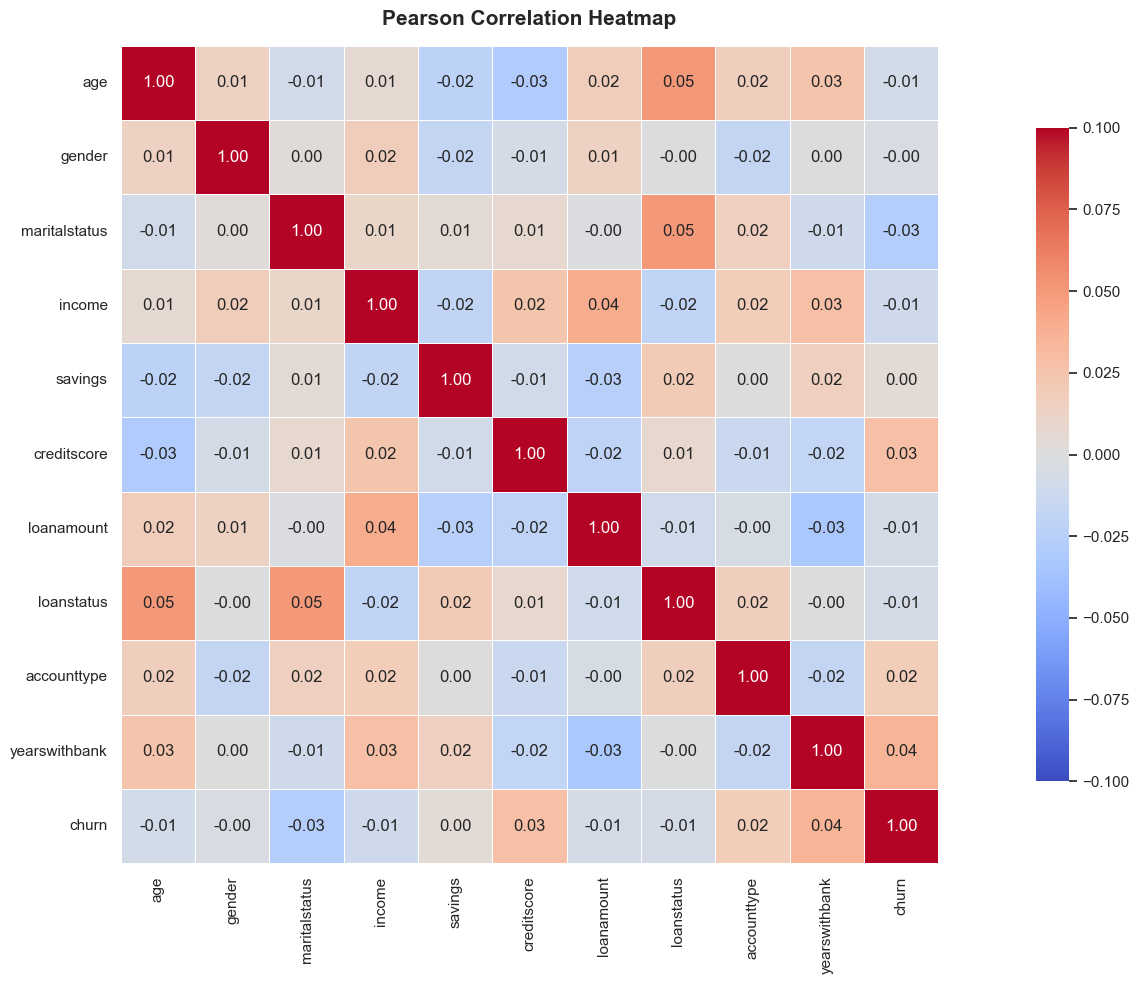

In [183]:
# Φτιάχνω ένα heatmap για το correlation v1

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-0.1,
    vmax=0.1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Η διαγώνιος είναι κόκκινη, κάθε feature συσχετίζεται απόλυτα με τον εαυτό του. yearswithbank με churn = 0.04 έχουν τη μεγαλύτερη συσχέτιση σε σχέση με churn vs άλλα feature

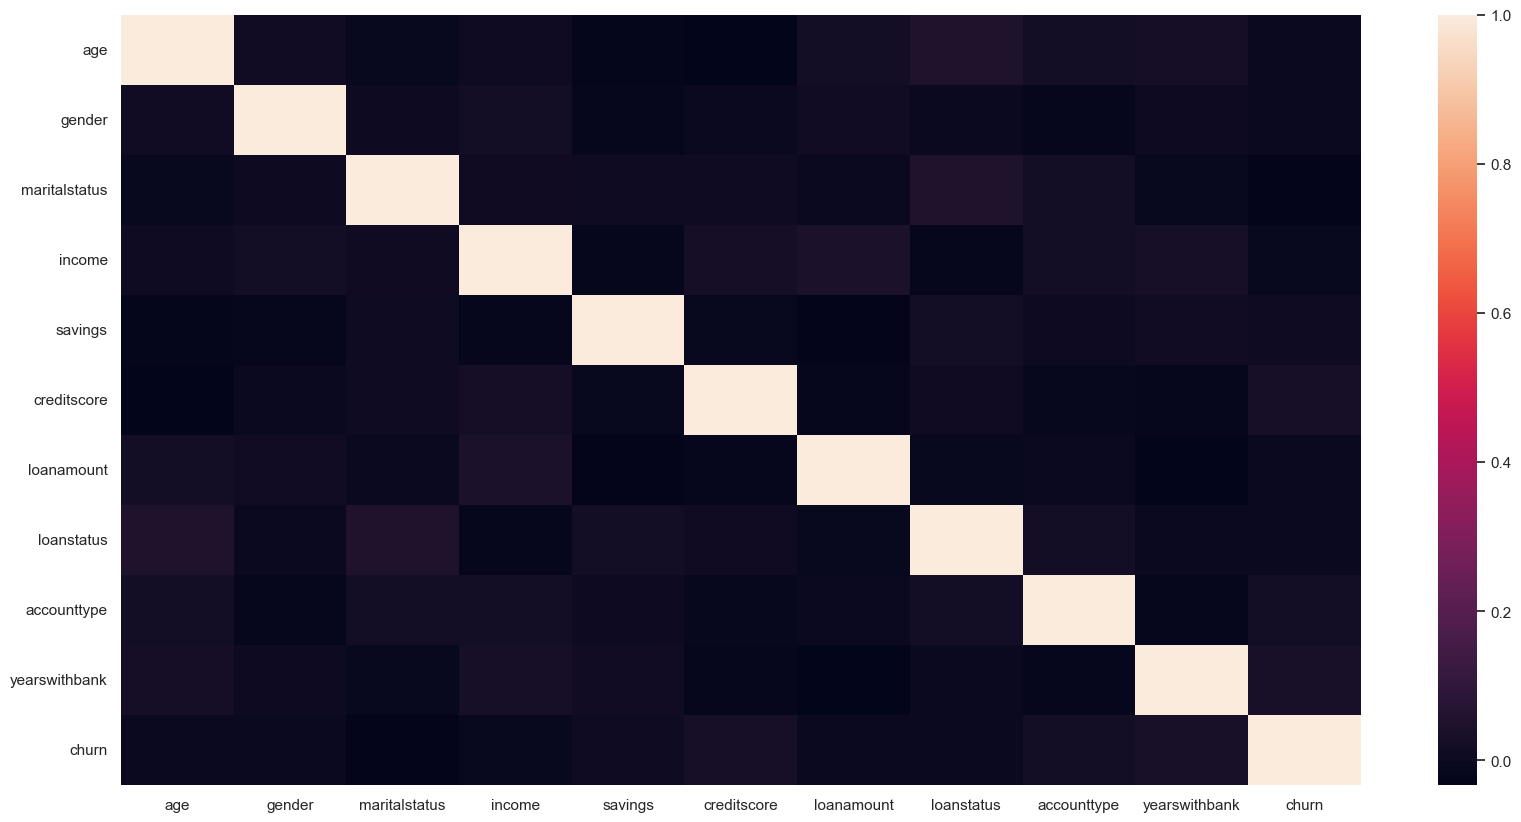

In [184]:
# Φτιάχνω ένα heatmap για το correlation v2

sns.set_theme()
sns.set_style()

fig, ax = plt.subplots(figsize=(20,10))

correlation_data = bank_customer_analytics_encoded.corr(numeric_only=True) # numeric_only=True αυτό δεν χρειάζεται γιατί το bank_customer_analytics_encoded είναι ήδη encoded, όλες οι στήλες είναι αριθμοί
#sns.heatmap(correlation_data, ax=ax, annot=True, fmt='.2f', cmap='coolwarm', center=0)
sns.heatmap(correlation_data, ax=ax)
plt.show()

### Σχεδόν όλος ο πίνακας είναι μαύρο - μωβ χρώμα. Ειδικά παρατηρούμε ότι κανένα feature δεν έχει γραμμική συσχέτιση με το churn

In [185]:
# Ψάχνω για συσχέτιση features pairs (|correlation| > 0.8)

threshold = 0.8
high_corr_pairs = []

for col1 in correlation_matrix.columns: # Ψάχνω όλα τα πιθανά ζευγάρια
    for col2 in correlation_matrix.columns:
        if col1 < col2: # Για να αποφύγω να ψάνω διπλά ζευγάρια
            correlation_value = correlation_matrix.loc[col1, col2]
            if abs(correlation_value) > threshold and col1 != 'churn' and col2 != 'churn': # Θέλω συσχέτιση μεγαλύτερη από 0.8 και βγάζω το churn, γιατί θέλω συσχέτιση μόνο features μεταξύ τους
                high_corr_pairs.append((col1, col2, round(correlation_value, 3))) # tuple 3αδας

if high_corr_pairs:
    print('Highly correlated feature pairs (|r| > 0.8):')
    for p in high_corr_pairs:
        print(f'  {p[0]} <-> {p[1]}: {p[2]}')  # --> Δείχνει feature1 με feature2: Πόση είναι η συσχέτιση μεταξύ τους
else:
    print('No feature pairs with |correlation| > 0.8 found.')  # Δεν βρίσκει ζευγάρι
    print('No features need to be dropped based on inter-correlation.')

No feature pairs with |correlation| > 0.8 found.
No features need to be dropped based on inter-correlation.


### Όλα τα feature είναι ανεξάρτητα το ένα από το άλλο. Οπότε με το correlation δεν χρειάζεται να πετάξω κάποιο feature

### Μέθοδος 2: Information Gain (Mutual Information)

In [187]:
from sklearn.feature_selection import mutual_info_classif

X = bank_customer_analytics_encoded.drop(columns=['churn'])
y = bank_customer_analytics_encoded['churn']

info_gain = mutual_info_classif(X, y, random_state=42)

for index, gain in enumerate(info_gain):
    print(f'Information Gain for {X.columns[index]} is: {gain:.3f}')

Information Gain for age is: 0.004
Information Gain for gender is: 0.005
Information Gain for maritalstatus is: 0.012
Information Gain for income is: 0.007
Information Gain for savings is: 0.006
Information Gain for creditscore is: 0.004
Information Gain for loanamount is: 0.011
Information Gain for loanstatus is: 0.000
Information Gain for accounttype is: 0.005
Information Gain for yearswithbank is: 0.000


### maritalstatus (0.012) και loanamount (0.011) έχουν τις μεγαλύτερες τιμές

### Μέθοδος 3: Random Forest Feature Importance (Tree-based)

In [188]:
# Βρίσκει μη γραμμικά μοτίβα

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y) # εδώ μέσα υπάρχει το churn. Το κάναμε defined στην μέθοδο 2

importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

         Feature  Importance
4        savings        0.15
9  yearswithbank        0.13
5    creditscore        0.12
0            age        0.11
6     loanamount        0.11
3         income        0.10
2  maritalstatus        0.09
8    accounttype        0.09
7     loanstatus        0.06
1         gender        0.05


### savings(0.15) και yearswithbank(0.13) δεν είχαν καλή επίδοση στις 2 παραπάνω μεθόδους αλλά στην Random Forest είναι τα πιο σημαντικά features

 ### Μέθοδος 4: RFE (Recursive Feature Elimination)

In [189]:
# Βρίσκει γραμμικά μοτίβα

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler

# Κάνει κανονικοποίηση: μετασχηματίζει τις τιμές όλων των χαρακτηριστικών ώστε να έχουν μέσο όρο = 0 και τυπική απόκλιση = 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Increase max_iter and change solver
rfe_model = LogisticRegression(max_iter=5000, random_state=42, solver='saga') # 5000 επαναλήψεις, saga:αλγόριθμος για μεγάλα datasets
rfe = RFE(estimator=rfe_model, n_features_to_select=5)
rfe.fit(X_scaled, y) # Logistic Regression: Εκπαιδεύεται και στα 10 features. Πετάει το πιο αδύναμο. Μετά πάλι εκπαιδεύσει τα 9 features πετάει το αδύναμο, μέχρι να καταλήξει στα 5 πιο σημαντικά.

rfe_df = pd.DataFrame({
    'Feature':  X.columns,
    'Selected': rfe.support_,
    'Ranking':  rfe.ranking_
}).sort_values('Ranking')

print(rfe_df.to_string(index=False))
print()
print('Selected features (Rank 1):', X.columns[rfe.support_].tolist()) # --> True σε όποιο επιλέγει
print('Eliminated features:', X.columns[~rfe.support_].tolist()) # --> ~ False σε όποιο απορρίπτει

      Feature  Selected  Ranking
maritalstatus      True        1
       income      True        1
  creditscore      True        1
  accounttype      True        1
yearswithbank      True        1
          age     False        2
   loanstatus     False        3
   loanamount     False        4
      savings     False        5
       gender     False        6

Selected features (Rank 1): ['maritalstatus', 'income', 'creditscore', 'accounttype', 'yearswithbank']
Eliminated features: ['age', 'gender', 'savings', 'loanamount', 'loanstatus']


### savings(0.15) στην Random Forest είναι σημαντικό feature αλλά στην RFE δεν είναι σημαντικό

### Μέθοδος 5: Gradient Boosting

In [191]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42) # Φτιάχνει 100 decision trees
gb.fit(X, y)

gb_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': gb.feature_importances_
}).sort_values(by='Importance', ascending=False) # Sort από το πιο σημαντικό στο λιγότερο σημαντικό

print(gb_df.to_string(index=False))

      Feature  Importance
yearswithbank        0.20
      savings        0.18
   loanamount        0.11
       income        0.11
  creditscore        0.10
maritalstatus        0.08
       gender        0.08
          age        0.05
  accounttype        0.05
   loanstatus        0.03


## 11.Domain-Specific Feature Understanding 

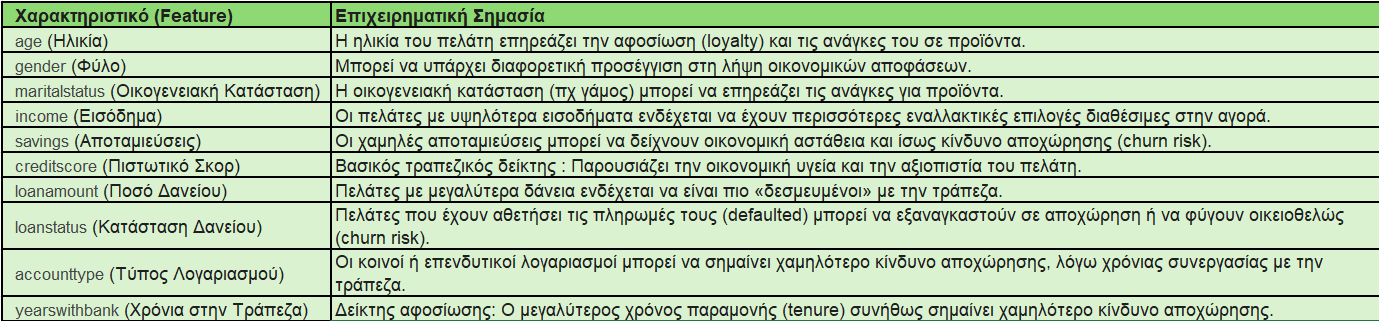

## Feature Selection: 

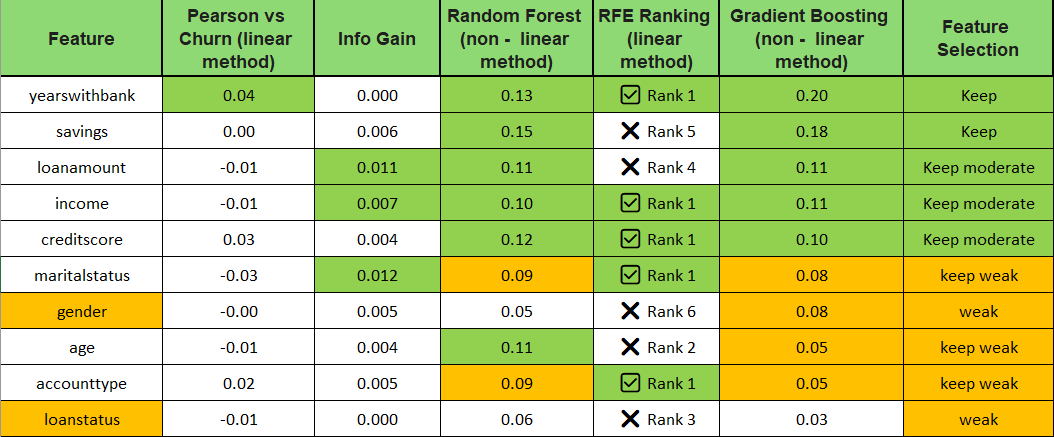

### Ελαστική Προσέγγιση - Κρατάμε όλα τα Features 

In [194]:
bank_customer_analytics_final_dataset = bank_customer_analytics.copy()

print('=== OPTION 1: Keep All Features ===')
print(f'Shape: {bank_customer_analytics_final_dataset.shape}')
print(f'Features: {bank_customer_analytics_final_dataset.columns.tolist()}')
print()
print('Conclusion: All 10 features + 1 target(churn) pass every selection criterion.')

# Είναι 10 τα features ουσιαστικά και το target που είναι το churn


=== OPTION 1: Keep All Features ===
Shape: (3000, 11)
Features: ['age', 'gender', 'maritalstatus', 'income', 'savings', 'creditscore', 'loanamount', 'loanstatus', 'accounttype', 'yearswithbank', 'churn']

Conclusion: All 10 features + 1 target(churn) pass every selection criterion.


### Συντηρητική Προσέγγιση - Πετάμε τα features gender & loanstatus

In [195]:
# --- OPTION 2: Drop gender and loanstatus ---
bank_customer_analytics_final_selected = bank_customer_analytics.drop(columns=['gender', 'loanstatus'])

print('=== OPTION 2: Drop gender and loanstatus ===')
print(f'Shape: {bank_customer_analytics_final_selected.shape}')
print(f'Features kept: {bank_customer_analytics_final_selected.columns.tolist()}')
print()
print('Justification:')
print('- gender    : lowest RF importance (0.05), near-zero Pearson, lowest RFE')
print('- loanstatus: zero Information Gain (0.000), lowest GB importance (0.03)')
print('Both are the weakest features across the 5 methods that we used.')

=== OPTION 2: Drop gender and loanstatus ===
Shape: (3000, 9)
Features kept: ['age', 'maritalstatus', 'income', 'savings', 'creditscore', 'loanamount', 'accounttype', 'yearswithbank', 'churn']

Justification:
- gender    : lowest RF importance (0.05), near-zero Pearson, lowest RFE
- loanstatus: zero Information Gain (0.000), lowest GB importance (0.03)
Both are the weakest features across the 5 methods that we used.


## Prepare Final Dataset: 

### Ελαστική Προσέγγιση - Κρατάμε όλα τα Features 

In [ ]:
bank_customer_analytics_final_dataset.to_csv('bank_customer_analytics_clean_all_features.csv', index=False)
print('🎉 Saved: bank_customer_analytics_clean_all_features.csv')
print(f'Shape: {bank_customer_analytics_final_dataset.shape}')
print(f'Missing values: {bank_customer_analytics_final_dataset.isna().sum().sum()}')

# windows key + . for emoji

🎉 Saved: bank_customer_analytics_clean_all_features.csv
Shape: (3000, 11)
Missing values: 0


### Συντηρητική Προσέγγιση - Πετάμε τα features gender & loanstatus

In [200]:
bank_customer_analytics_final_selected.to_csv('bank_customer_analytics_clean_selected.csv', index=False)
print('😎Saved: bank_customer_analytics_clean_selected.csv')
print(f'Shape: {bank_customer_analytics_final_selected.shape}')
print(f'Missing values: {bank_customer_analytics_final_selected.isna().sum().sum()}')

😎Saved: bank_customer_analytics_clean_selected.csv
Shape: (3000, 9)
Missing values: 0
